# Chapter 9 — Prediction data preparation (full rebuild)

Rebuilds the NUTS-3 monthly prediction panel for **2018–2025** from NL-clipped hydro-meteorological rasters, CLC land cover, WorldPop population, elevation, soil composition, and the drought-impact database.

**Scope**
- Spatial unit: Dutch NUTS-3 (40 regions)
- Period: 2018-01 → 2025-12 (development 2018–2023, test 2024–2025)
- Targets: top-10 impact classes, multi-label, horizons h = 0, 1, 2, 3
- Predictors: SPI/SPEI (1–24), soil moisture anomaly, CDD, land cover, population, elevation, soil composition, seasonality + impact lags

**Outputs** (under `Data/processed/`)
- `meteo_nuts3_monthly_2018_2025.parquet` (+ csv)
- `static_land_cover_nuts3.parquet`, `static_population_nuts3.parquet`
- `static_elevation_nuts3.parquet`, `static_soil_composition_nuts3.parquet`
- `supervised_nuts3_forecast_2018_2025.parquet` (+ csv)
- QA tables: missingness, class counts, coverage


## 0. Config and paths

In [1]:
%matplotlib inline

from __future__ import annotations

import importlib
import re
import sys
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
from rasterio.features import rasterize
from rasterio.transform import xy
from rasterio.windows import from_bounds
from shapely.geometry import Point

PACKAGE_ROOT = Path("..").resolve()
if not (PACKAGE_ROOT / "data").exists():
    PACKAGE_ROOT = Path(".").resolve()
    if PACKAGE_ROOT.name == "notebooks":
        PACKAGE_ROOT = PACKAGE_ROOT.parent

sys.path.insert(0, str(PACKAGE_ROOT / "src"))
import soil_tif_utils
importlib.reload(soil_tif_utils)
from soil_tif_utils import SOIL_DATA_FOLDER, read_soil_tif_bytes

try:
    import pyarrow  # noqa: F401
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyarrow"])

NL_DIR = PACKAGE_ROOT / "data" / "meteo_nl"
STATIC_DIR = PACKAGE_ROOT / "data" / "static"
LAND_DIR = STATIC_DIR / "land"
POP_DIR = STATIC_DIR / "population"
CLC_TIF = LAND_DIR / "U2018_CLC2018_V2020_20u1.tif"
CLC_LEGEND = LAND_DIR / "CLC2018_CLC2018_V2018_20_QGIS.txt"
CLC_LEGEND_PATH = CLC_LEGEND  # alias
POP_TIF = POP_DIR / "nld_pop_2018_CN_100m_R2025A_v1.tif"
Y_PATH = PACKAGE_ROOT / "data" / "input" / "impacts_nuts3.csv"
NUTS_GEOJSON = PACKAGE_ROOT / "data" / "input" / "nuts_nl_simplified.geojson"
OUT_DIR = PACKAGE_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Aliases used by some legacy cell snippets
NOTEBOOK_DIR = PACKAGE_ROOT
CHAPTER7_DIR = PACKAGE_ROOT
CHAPTERS_DIR = PACKAGE_ROOT

SCAFFOLD_START = pd.Timestamp("2018-01-01")
SCAFFOLD_END = pd.Timestamp("2025-12-01")
DEV_END_YEAR = 2023
TIMESCALES = ["1", "3", "6", "9", "12", "24"]
MONTHLY_PERIOD_NAMES = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec",
]
FORECAST_HORIZONS = [0, 1, 2, 3]

TOP_10_CLASSES = [
    "Crop Failure & Yield Reduction",
    "Reservoir & Surface Water Shortage",
    "Freshwater Ecosystem Degradation",
    "Groundwater Depletion",
    "Water Use Restrictions",
    "Forest Dieback & Vegetation Stress",
    "Agricultural Economic Loss",
    "Irrigation Shortage",
    "Water Supply & Sanitation Issues",
    "Wildfire Occurrence",
]

KEY_COLS = ["year_month", "nuts3_id", "nuts3_name", "nuts2_id", "nuts2_name"]

for path, label in [
    (NL_DIR, "NL meteo"),
    (NUTS_GEOJSON, "NUTS geojson"),
    (CLC_TIF, "CLC raster"),
    (POP_TIF, "Population raster"),
    (Y_PATH, "Impact labels"),
]:
    if not path.exists():
        raise FileNotFoundError(f"{label} not found: {path}")

print(f"Package:  {PACKAGE_ROOT}")
print(f"NL meteo: {NL_DIR}")
print(f"Output:   {OUT_DIR}")
print(f"Scaffold: {SCAFFOLD_START:%Y-%m} -> {SCAFFOLD_END:%Y-%m}")
print(f"SPI/SPEI scales: {TIMESCALES}")
print(f"Top-10 classes: {len(TOP_10_CLASSES)}")


Package:  C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting
NL meteo: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\meteo_nl
Output:   C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed
Scaffold: 2018-01 -> 2025-12
SPI/SPEI scales: ['1', '3', '6', '9', '12', '24']
Top-10 classes: 10


## 1. Helpers — spatial aggregation and time normalization

In [2]:
def to_year_month(ts: pd.Timestamp) -> pd.Timestamp:
    return pd.Timestamp(ts).to_period("M").to_timestamp()


def to_month(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series).dt.to_period("M").dt.to_timestamp()


def derive_impact_month(df: pd.DataFrame) -> pd.Series:
    recency_days = df["recency_in_months"].fillna(0).astype(int) * 30
    return to_month(df["publication_date"] - pd.to_timedelta(recency_days, unit="D"))


def build_cell_nuts3_map(lats: np.ndarray, lons: np.ndarray, nuts3: gpd.GeoDataFrame) -> pd.DataFrame:
    rows: list[dict] = []
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            rows.append({"i": i, "j": j, "lat": float(lat), "lon": float(lon)})
    points = gpd.GeoDataFrame(
        rows,
        geometry=[Point(r["lon"], r["lat"]) for r in rows],
        crs="EPSG:4326",
    )
    nuts3_poly = nuts3[["nuts3_id", "geometry"]]
    joined = gpd.sjoin(points, nuts3_poly, how="left", predicate="within")
    if "index_right" in joined.columns:
        joined = joined.drop(columns=["index_right"])
    return joined[joined["nuts3_id"].notna()].reset_index(drop=True)


def groups_from_cell_map(cell_map: pd.DataFrame) -> dict[str, list[tuple[int, int]]]:
    groups: dict[str, list[tuple[int, int]]] = {}
    for nuts3_id, grp in cell_map.groupby("nuts3_id"):
        groups[str(nuts3_id)] = list(zip(grp["i"].astype(int), grp["j"].astype(int)))
    return groups


def complete_groups_with_nearest_cell(
    groups: dict[str, list[tuple[int, int]]],
    lats: np.ndarray,
    lons: np.ndarray,
    nuts3: gpd.GeoDataFrame,
) -> tuple[dict[str, list[tuple[int, int]]], list[str]]:
    out = {k: list(v) for k, v in groups.items()}
    fallback: list[str] = []
    lat_grid, lon_grid = np.meshgrid(lats, lons, indexing="ij")
    for _, row in nuts3.iterrows():
        nuts3_id = str(row["nuts3_id"])
        if nuts3_id in out and out[nuts3_id]:
            continue
        pt = row.geometry.representative_point()
        dist2 = (lat_grid - pt.y) ** 2 + (lon_grid - pt.x) ** 2
        i, j = np.unravel_index(int(np.nanargmin(dist2)), dist2.shape)
        out[nuts3_id] = [(int(i), int(j))]
        fallback.append(nuts3_id)
    return out, fallback


def build_spei_spi_groups(
    lats: np.ndarray,
    lons: np.ndarray,
    nuts3: gpd.GeoDataFrame,
) -> tuple[dict[str, list[tuple[int, int]]], list[str]]:
    cell_map = build_cell_nuts3_map(lats, lons, nuts3)
    return complete_groups_with_nearest_cell(groups_from_cell_map(cell_map), lats, lons, nuts3)


def sanitize_grid(data: np.ndarray) -> np.ndarray:
    out = np.asarray(data, dtype=float)
    return np.where(np.isfinite(out), out, np.nan)


def zonal_mean_from_groups(data: np.ndarray, groups: dict[str, list[tuple[int, int]]]) -> dict[str, float]:
    out: dict[str, float] = {}
    for nuts3_id, idxs in groups.items():
        vals = np.array([data[i, j] for i, j in idxs], dtype=float)
        out[nuts3_id] = np.nan if vals.size == 0 or np.all(np.isnan(vals)) else float(np.nanmean(vals))
    return out


def dedupe_monthly(df: pd.DataFrame, value_col: str = "value") -> pd.DataFrame:
    if df.empty:
        return df
    return df.groupby(["year_month", "nuts3_id"], as_index=False)[value_col].mean()


def zonal_mean_netcdf(folder: Path, var_name: str, groups: dict[str, list[tuple[int, int]]]) -> pd.DataFrame:
    records: list[dict] = []
    for path in sorted(folder.glob("*.nc")):
        with xr.open_dataset(path) as ds:
            da = ds[var_name]
            for t_idx in range(da.sizes.get("time", 1)):
                ts = pd.Timestamp(ds["time"].values[t_idx])
                data = sanitize_grid(np.squeeze(da.isel(time=t_idx).values))
                for nuts3_id, val in zonal_mean_from_groups(data, groups).items():
                    records.append({"year_month": to_year_month(ts), "nuts3_id": nuts3_id, "value": val})
    if not records:
        return pd.DataFrame(columns=["year_month", "nuts3_id", "value"])
    return dedupe_monthly(pd.DataFrame(records))


def resample_to_monthly(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    return df.groupby(["year_month", "nuts3_id"], as_index=False)["value"].mean()


def iter_soil_slices(folder: Path):
    pattern = re.compile(r"_(\d{8})_")
    for zip_path in sorted(folder.glob("*.zip")):
        with zipfile.ZipFile(zip_path) as zf:
            for name in sorted(n for n in zf.namelist() if n.lower().endswith(".tif")):
                match = pattern.search(name)
                if not match:
                    continue
                ts = pd.to_datetime(match.group(1), format="%Y%m%d")
                arr, _, _, transform = read_soil_tif_bytes(zf.read(name))
                yield ts, arr, transform, arr.shape[0], arr.shape[1]


def build_soil_cell_map(folder: Path, nuts3: gpd.GeoDataFrame) -> tuple[dict[str, list[tuple[int, int]]], pd.DataFrame]:
    for _ts, _arr, transform, h, w in iter_soil_slices(folder):
        rows: list[dict] = []
        for i in range(h):
            for j in range(w):
                lon, lat = xy(transform, i, j)
                rows.append({"i": i, "j": j, "lat": float(lat), "lon": float(lon)})
        points = gpd.GeoDataFrame(
            rows,
            geometry=[Point(r["lon"], r["lat"]) for r in rows],
            crs="EPSG:4326",
        )
        joined = gpd.sjoin(points, nuts3[["nuts3_id", "geometry"]], how="left", predicate="within")
        if "index_right" in joined.columns:
            joined = joined.drop(columns=["index_right"])
        cell_map = joined[joined["nuts3_id"].notna()].reset_index(drop=True)
        return groups_from_cell_map(cell_map), cell_map
    raise FileNotFoundError(f"No soil tifs in {folder}")


def zonal_mean_soil(folder: Path, groups: dict[str, list[tuple[int, int]]]) -> pd.DataFrame:
    records: list[dict] = []
    for ts, arr, *_ in iter_soil_slices(folder):
        arr = sanitize_grid(arr)
        for nuts3_id, val in zonal_mean_from_groups(arr, groups).items():
            records.append({"year_month": to_year_month(ts), "nuts3_id": nuts3_id, "value": val})
    return dedupe_monthly(pd.DataFrame(records))


print("Helpers ready.")


Helpers ready.


## 2. NUTS-3 boundaries and 2018–2025 scaffold

In [3]:
def load_nuts3_with_nuts2() -> gpd.GeoDataFrame:
    gdf = gpd.read_file(NUTS_GEOJSON)
    nuts2 = gdf[gdf["LEVL_CODE"] == 2][["NUTS_ID", "NAME_LATN", "geometry"]].copy()
    nuts3 = gdf[gdf["LEVL_CODE"] == 3][["NUTS_ID", "NAME_LATN", "geometry"]].copy()
    pts = nuts3.copy()
    pts["geometry"] = pts.geometry.representative_point()
    nuts2_attr = nuts2.rename(columns={"NUTS_ID": "nuts2_id", "NAME_LATN": "nuts2_name"})[
        ["nuts2_id", "nuts2_name", "geometry"]
    ]
    joined = gpd.sjoin(pts[["NUTS_ID", "geometry"]], nuts2_attr, how="left", predicate="within")
    if "index_right" in joined.columns:
        joined = joined.drop(columns=["index_right", "geometry"])
    meta = nuts3.merge(joined, on="NUTS_ID", how="left")
    return meta.rename(columns={"NUTS_ID": "nuts3_id", "NAME_LATN": "nuts3_name"})


def build_scaffold(nuts3_meta: gpd.GeoDataFrame) -> pd.DataFrame:
    months = pd.date_range(SCAFFOLD_START, SCAFFOLD_END, freq="MS")
    meta = nuts3_meta[["nuts3_id", "nuts3_name", "nuts2_id", "nuts2_name"]].drop_duplicates()
    scaffold = meta.assign(key=1).merge(pd.DataFrame({"year_month": months, "key": 1}), on="key").drop(columns="key")
    return scaffold.sort_values(["year_month", "nuts3_id"]).reset_index(drop=True)


nuts3_full = load_nuts3_with_nuts2()
nuts3 = nuts3_full[["nuts3_id", "nuts3_name", "geometry"]].copy()
scaffold = build_scaffold(nuts3_full)

n_regions = nuts3["nuts3_id"].nunique()
n_months = scaffold["year_month"].nunique()
print(f"NUTS3 regions: {n_regions}")
print(f"Scaffold rows: {len(scaffold):,}  ({scaffold['year_month'].min().date()} -> {scaffold['year_month'].max().date()})")
print(f"Expected: {n_regions} x {n_months} = {n_regions * n_months}")
assert n_regions == 40
assert n_months == 96
assert len(scaffold) == 3840


NUTS3 regions: 40
Scaffold rows: 3,840  (2018-01-01 -> 2025-12-01)
Expected: 40 x 96 = 3840


## 3. Rebuild hydro-meteorological panel

Zonal means of NL-clipped SPEI, SPI, soil moisture anomaly, and ECA CDD.
CDI and drought-news fraction are **not** included (outside thesis predictor table).
SPI/SPEI timescales: 1, 3, 6, 9, 12, 24 months.


In [4]:
with xr.open_dataset(sorted((NL_DIR / "SPEI 1991-2026" / "12").glob("*.nc"))[0]) as ds:
    spei_cell_map = build_cell_nuts3_map(ds["lat"].values, ds["lon"].values, nuts3)
    spei_groups, spei_fallback = build_spei_spi_groups(ds["lat"].values, ds["lon"].values, nuts3)

soil_groups, soil_cell_map = build_soil_cell_map(NL_DIR / SOIL_DATA_FOLDER, nuts3)

print(f"SPEI grid cells mapped: {len(spei_cell_map)}")
print(
    f"SPEI nearest-cell fallback ({len(spei_fallback)}): "
    f"{', '.join(sorted(spei_fallback)) or 'none'}"
)
print(f"Soil grid cells mapped: {len(soil_cell_map)}")


SPEI grid cells mapped: 79
SPEI nearest-cell fallback (5): NL323, NL325, NL327, NL333, NL337
Soil grid cells mapped: 1973


In [5]:
def process_spei_spi(root: Path, prefix: str, col_prefix: str) -> pd.DataFrame:
    out: pd.DataFrame | None = None
    for scale in TIMESCALES:
        folder = root / scale
        var_name = f"{prefix}{scale.zfill(2)}"
        nc_files = sorted(folder.glob("*.nc"))
        if not nc_files:
            raise FileNotFoundError(f"No NetCDF files in {folder}")
        with xr.open_dataset(nc_files[0]) as ds:
            groups, _ = build_spei_spi_groups(ds["lat"].values, ds["lon"].values, nuts3)
        ts_df = zonal_mean_netcdf(folder, var_name, groups)
        col = f"{col_prefix}_{scale.zfill(2)}"
        ts_df = ts_df.rename(columns={"value": col})
        out = ts_df if out is None else out.merge(ts_df, on=["year_month", "nuts3_id"], how="outer")
        print(f"  {col}: {len(ts_df):,} rows  "
              f"({ts_df['year_month'].min():%Y-%m} -> {ts_df['year_month'].max():%Y-%m})")
    return out if out is not None else pd.DataFrame(columns=["year_month", "nuts3_id"])


print("Processing SPEI...")
spei = process_spei_spi(NL_DIR / "SPEI 1991-2026", "spe", "spei")
print("Processing SPI...")
spi = process_spei_spi(NL_DIR / "SPI 1991-2026", "spa", "spi")

print("Processing soil moisture...")
soil_raw = zonal_mean_soil(NL_DIR / SOIL_DATA_FOLDER, soil_groups)
soil = resample_to_monthly(soil_raw).rename(columns={"value": "soil_moisture_anom"})
print(
    f"  soil_moisture_anom: {len(soil):,} rows  "
    f"({soil['year_month'].min():%Y-%m} -> {soil['year_month'].max():%Y-%m})"
)

print(f"SPEI rows: {len(spei):,}  SPI rows: {len(spi):,}  Soil rows: {len(soil):,}")


Processing SPEI...
  spei_01: 17,000 rows  (1991-01 -> 2026-05)
  spei_03: 17,000 rows  (1991-01 -> 2026-05)
  spei_06: 17,000 rows  (1991-01 -> 2026-05)
  spei_09: 17,000 rows  (1991-01 -> 2026-05)
  spei_12: 16,040 rows  (1993-01 -> 2026-05)
  spei_24: 17,000 rows  (1991-01 -> 2026-05)
Processing SPI...
  spi_01: 17,000 rows  (1991-01 -> 2026-05)
  spi_03: 17,000 rows  (1991-01 -> 2026-05)
  spi_06: 17,000 rows  (1991-01 -> 2026-05)
  spi_09: 16,040 rows  (1993-01 -> 2026-05)
  spi_12: 17,000 rows  (1991-01 -> 2026-05)
  spi_24: 17,000 rows  (1991-01 -> 2026-05)
Processing soil moisture...
  soil_moisture_anom: 10,800 rows  (2004-01 -> 2026-06)
SPEI rows: 17,000  SPI rows: 17,000  Soil rows: 10,800


In [6]:
def process_eca() -> pd.DataFrame:
    eca_dir = NL_DIR / "ECA_indexCDD"
    stations = pd.read_csv(eca_dir / "eca_nl_stations.csv")
    series = pd.read_csv(eca_dir / "eca_nl_timeseries.csv")
    period_to_month = {name: i for i, name in enumerate(MONTHLY_PERIOD_NAMES, start=1)}
    series = series[series["period"].isin(MONTHLY_PERIOD_NAMES)].copy()
    series["year_month"] = series.apply(
        lambda r: pd.Timestamp(int(r["year"]), period_to_month[r["period"]], 1), axis=1
    )
    st_gdf = gpd.GeoDataFrame(
        stations,
        geometry=[Point(lon, lat) for lon, lat in zip(stations["longitude"], stations["latitude"])],
        crs="EPSG:4326",
    )
    st_joined = gpd.sjoin(st_gdf, nuts3[["nuts3_id", "geometry"]], how="left", predicate="within")
    if "index_right" in st_joined.columns:
        st_joined = st_joined.drop(columns=["index_right"])
    st_map = st_joined[["staid", "nuts3_id"]].dropna()
    merged = series.merge(st_map, on="staid", how="inner")
    return (
        merged.groupby(["year_month", "nuts3_id"], as_index=False)
        .agg(cdd_days=("cdd_days", "mean"), cdd_station_count=("staid", "nunique"))
    )


print("Processing ECA CDD...")
eca = process_eca()
print(
    f"ECA rows: {len(eca):,}  "
    f"({eca['year_month'].min():%Y-%m} -> {eca['year_month'].max():%Y-%m})"
)


Processing ECA CDD...
ECA rows: 11,040  (2004-01 -> 2026-12)


In [7]:
meteo_panel = scaffold.copy()
for feat in (spei, spi, soil, eca):
    meteo_panel = meteo_panel.merge(feat, on=["year_month", "nuts3_id"], how="left")

meteo_panel = meteo_panel.sort_values(["year_month", "nuts3_id"]).reset_index(drop=True)
meteo_feature_cols = [c for c in meteo_panel.columns if c not in KEY_COLS]
meteo_panel = meteo_panel[KEY_COLS + meteo_feature_cols]

# Coverage assertions
assert meteo_panel[["year_month", "nuts3_id"]].duplicated().sum() == 0
assert meteo_panel["nuts3_id"].nunique() == 40
assert meteo_panel["year_month"].min() == SCAFFOLD_START
assert meteo_panel["year_month"].max() == SCAFFOLD_END
assert len(meteo_panel) == 3840
forbidden = [c for c in meteo_panel.columns if c.endswith("_48") or c == "cdi"]
assert not forbidden, f"Unexpected columns present: {forbidden}"

meteo_parquet = OUT_DIR / "meteo_nuts3_monthly_2018_2025.parquet"
meteo_csv = OUT_DIR / "meteo_nuts3_monthly_2018_2025.csv"
meteo_panel.to_parquet(meteo_parquet, index=False)
meteo_panel.to_csv(meteo_csv, index=False)

print(f"Rows: {len(meteo_panel):,}  Regions: {meteo_panel['nuts3_id'].nunique()}  Features: {len(meteo_feature_cols)}")
print(f"Saved: {meteo_parquet}")
print(f"Saved: {meteo_csv}")
print("\nNull % per feature (2018-2025 scaffold):")
miss_rows = []
for col in meteo_feature_cols:
    pct = 100 * meteo_panel[col].isna().mean()
    miss_rows.append({"feature": col, "missing_pct": round(pct, 2)})
    print(f"  {col:22s} {pct:6.1f}%")
meteo_missingness = pd.DataFrame(miss_rows)
meteo_missingness.to_csv(OUT_DIR / "qa_meteo_missingness.csv", index=False)
meteo_panel.head()


Rows: 3,840  Regions: 40  Features: 15
Saved: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\meteo_nuts3_monthly_2018_2025.parquet
Saved: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed\meteo_nuts3_monthly_2018_2025.csv

Null % per feature (2018-2025 scaffold):
  spei_01                   0.0%
  spei_03                   0.0%
  spei_06                   0.0%
  spei_09                   0.0%
  spei_12                   0.0%
  spei_24                   0.0%
  spi_01                    0.0%
  spi_03                    0.0%
  spi_06                    0.0%
  spi_09                    0.0%
  spi_12                    0.0%
  spi_24                    0.0%
  soil_moisture_anom        0.0%
  cdd_days                  0.2%
  cdd_station_count         0

,year_month,nuts3_id,nuts3_name,nuts2_id,nuts2_name,spei_01,spei_03,spei_06,spei_09,spei_12,spei_24,spi_01,spi_03,spi_06,spi_09,spi_12,spi_24,soil_moisture_anom,cdd_days,cdd_station_count
0,2018-01-01,NL111,Oost-Groningen,NL11,Groningen,0.816174,0.728035,0.599726,0.883515,0.833686,0.031710,0.811240,0.771727,0.669890,0.997886,0.945446,0.110225,0.577292,4.000000,9
1,2018-01-01,NL112,Delfzijl en omgeving,NL11,Groningen,0.916780,0.919816,0.838927,1.039512,0.948271,-0.142348,0.888453,0.900830,0.850656,1.107403,1.015488,-0.079962,0.711784,3.666667,3
2,2018-01-01,NL113,Overig Groningen,NL11,Groningen,0.925218,0.861745,0.825605,0.997649,0.885388,-0.170349,0.896123,0.858816,0.846411,1.090223,0.987861,-0.084849,0.643988,4.062500,16
3,2018-01-01,NL124,Noord-Friesland,NL12,Friesland (NL),0.868603,0.598546,0.907697,0.974276,0.809056,-0.352390,0.856615,0.622396,0.899370,1.092274,0.956421,-0.202141,0.652579,4.066667,30
4,2018-01-01,NL125,Zuidwest-Friesland,NL12,Friesland (NL),0.690825,0.342424,0.634035,0.685715,0.602192,-0.483298,0.727257,0.386570,0.667318,0.867756,0.764616,-0.342545,0.734086,4.000000,11


## 4. Rebuild static regional features (land cover, population, elevation, soil)

Land cover and population are aggregated from rasters here. Elevation and soil composition are loaded from the Chapter 9 EDA exports (`static_elevation_nuts3.parquet`, `soil_nuts3_mainclass_fractions.parquet`) and written to a stable modelling schema.


In [8]:
# CLC 2018 -> NUTS3 cover fractions
legend_df = pd.read_csv(
    CLC_LEGEND,
    header=None,
    names=["clc_code", "R", "G", "B", "A", "label"],
)
legend_df = legend_df[legend_df["clc_code"] != 999].reset_index(drop=True)
legend_df.insert(0, "grid_code", np.arange(1, len(legend_df) + 1))
_max_code = int(legend_df["grid_code"].max())

CROP_GRID = set(range(12, 23))
TREE_GRID = {23, 24, 25, 29}
WATER_GRID = set(range(35, 45))

def _grid_to_super(grid_code: int) -> str:
    if grid_code in CROP_GRID:
        return "crop"
    if grid_code in TREE_GRID:
        return "tree"
    if grid_code in WATER_GRID:
        return "water"
    return "other"

_SUPER_TO_ID = {"other": 0, "crop": 1, "tree": 2, "water": 3}
_super_lookup = np.zeros(_max_code + 1, dtype=np.uint8)
for code in range(1, _max_code + 1):
    _super_lookup[code] = _SUPER_TO_ID[_grid_to_super(code)]

BUFFER_M = 500
nuts3_nl = nuts3.sort_values("nuts3_id").reset_index(drop=True)

with rasterio.open(CLC_TIF) as src:
    clc_crs = src.crs
    nuts3_clc = nuts3_nl.to_crs(clc_crs)
    minx, miny, maxx, maxy = nuts3_clc.total_bounds
    minx -= BUFFER_M
    miny -= BUFFER_M
    maxx += BUFFER_M
    maxy += BUFFER_M
    window = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
    window = window.round_offsets().round_lengths()
    clc_nl = src.read(1, window=window)
    clc_transform = src.window_transform(window)

region_ids = nuts3_clc["nuts3_id"].tolist()
id_to_label = {i + 1: rid for i, rid in enumerate(region_ids)}
nuts3_raster = rasterize(
    [(geom, i + 1) for i, geom in enumerate(nuts3_clc.geometry)],
    out_shape=clc_nl.shape,
    transform=clc_transform,
    fill=0,
    dtype=np.uint16,
    all_touched=False,
)

clc_int = clc_nl.astype(np.int32)
valid_mask = (clc_int >= 1) & (clc_int <= _max_code)
land_records = []
for label, nuts3_id in id_to_label.items():
    region_mask = (nuts3_raster == label) & valid_mask
    n_valid = int(region_mask.sum())
    if n_valid == 0:
        land_records.append({
            "nuts3_id": nuts3_id,
            "crop_cover_fraction": np.nan,
            "tree_cover_fraction": np.nan,
            "water_cover_fraction": np.nan,
            "n_valid_pixels": 0,
        })
        continue
    codes = clc_int[region_mask]
    super_ids = _super_lookup[codes]
    land_records.append({
        "nuts3_id": nuts3_id,
        "crop_cover_fraction": int((super_ids == 1).sum()) / n_valid,
        "tree_cover_fraction": int((super_ids == 2).sum()) / n_valid,
        "water_cover_fraction": int((super_ids == 3).sum()) / n_valid,
        "n_valid_pixels": n_valid,
    })

static_land = pd.DataFrame(land_records).merge(
    nuts3_nl[["nuts3_id", "nuts3_name"]], on="nuts3_id", how="left"
)
static_land["area_km2_approx"] = static_land["n_valid_pixels"] * 0.01

missing_land = static_land.loc[static_land["n_valid_pixels"] == 0, "nuts3_id"].tolist()
if missing_land:
    print("WARNING: regions with zero valid CLC pixels:", missing_land)
else:
    print("All regions have valid CLC coverage.")

land_export_cols = [
    "nuts3_id", "nuts3_name",
    "crop_cover_fraction", "tree_cover_fraction", "water_cover_fraction",
    "n_valid_pixels", "area_km2_approx",
]
land_parquet = OUT_DIR / "static_land_cover_nuts3.parquet"
land_csv = OUT_DIR / "static_land_cover_nuts3.csv"
static_land[land_export_cols].to_parquet(land_parquet, index=False)
static_land[land_export_cols].to_csv(land_csv, index=False)
print(f"Saved: {land_parquet.name}")
display(static_land[land_export_cols].describe().round(3))


C:\Users\hoeven\AppData\Local\Temp\ipykernel_17348\645028432.py:42: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  clc_nl = src.read(1, window=window)


All regions have valid CLC coverage.
Saved: static_land_cover_nuts3.parquet


,crop_cover_fraction,tree_cover_fraction,water_cover_fraction,n_valid_pixels,area_km2_approx
count,40.000,40.000,40.000,40.000,40.000
mean,0.625,0.077,0.081,93397.575,933.976
std,0.173,0.070,0.106,55279.530,552.795
min,0.179,0.000,0.003,12769.000,127.690
25%,0.545,0.014,0.021,49093.250,490.932
50%,0.647,0.071,0.044,89742.000,897.420
75%,0.751,0.121,0.077,140211.000,1402.110
max,0.866,0.336,0.423,241016.000,2410.160


In [9]:
# WorldPop 2018 -> NUTS3 population shares
with rasterio.open(POP_TIF) as src:
    pop = src.read(1, masked=True)
    transform = src.transform
    # WorldPop is typically EPSG:4326; NUTS geojson is also 4326
    nuts3_pop = nuts3_nl.to_crs(src.crs) if src.crs else nuts3_nl
    region_ids = nuts3_pop["nuts3_id"].tolist()
    id_to_label = {rid: i + 1 for i, rid in enumerate(region_ids)}
    nuts3_raster = rasterize(
        [(geom, id_to_label[rid]) for rid, geom in zip(region_ids, nuts3_pop.geometry)],
        out_shape=pop.shape,
        transform=transform,
        fill=0,
        dtype=np.uint16,
        all_touched=False,
    )

total_nl_population = float(pop.compressed().sum())
pop_records = []
for rid in region_ids:
    label = id_to_label[rid]
    region_mask = (nuts3_raster == label) & ~pop.mask
    region_pop = float(pop[region_mask].sum())
    pop_records.append({
        "nuts3_id": rid,
        "population_count": region_pop,
        "population_fraction": region_pop / total_nl_population,
        "n_valid_pixels": int(region_mask.sum()),
    })

static_pop = pd.DataFrame(pop_records).merge(
    nuts3_nl[["nuts3_id", "nuts3_name"]], on="nuts3_id", how="left"
)

assigned = static_pop["population_count"].sum()
print(f"Total NL population (raster): {total_nl_population:,.0f}")
print(f"Assigned to NUTS3:            {assigned:,.0f}")
print(f"Sum of fractions:             {static_pop['population_fraction'].sum():.6f}")
missing_pop = static_pop.loc[static_pop["n_valid_pixels"] == 0, "nuts3_id"].tolist()
if missing_pop:
    print("WARNING: regions with zero valid population pixels:", missing_pop)
else:
    print("All regions have valid population coverage.")

pop_export_cols = [
    "nuts3_id", "nuts3_name", "population_count", "population_fraction", "n_valid_pixels",
]
pop_parquet = OUT_DIR / "static_population_nuts3.parquet"
pop_csv = OUT_DIR / "static_population_nuts3.csv"
static_pop[pop_export_cols].to_parquet(pop_parquet, index=False)
static_pop[pop_export_cols].to_csv(pop_csv, index=False)
print(f"Saved: {pop_parquet.name}")
display(static_pop[pop_export_cols].describe().round(4))


Total NL population (raster): 17,369,228
Assigned to NUTS3:            17,353,599
Sum of fractions:             0.999100
All regions have valid population coverage.
Saved: static_population_nuts3.parquet


,population_count,population_fraction,n_valid_pixels
count,4.000000e+01,40.0000,40.0000
mean,4.338400e+05,0.0250,90226.5250
std,3.375293e+05,0.0194,51749.5034
min,4.807505e+04,0.0028,14441.0000
25%,1.972429e+05,0.0114,52665.2500
50%,3.319977e+05,0.0191,83626.0000
75%,6.142923e+05,0.0354,120987.7500
max,1.446101e+06,0.0833,198733.0000


In [10]:
# Elevation + soil composition (from Chapter 9 EDA exports)
import re
import unicodedata

ELEV_PATH = OUT_DIR / "static_elevation_nuts3.parquet"
SOIL_SRC_PATH = OUT_DIR / "soil_nuts3_mainclass_fractions.parquet"

if not ELEV_PATH.exists():
    raise FileNotFoundError(f"Elevation static table not found: {ELEV_PATH}")
if not SOIL_SRC_PATH.exists():
    raise FileNotFoundError(f"Soil fractions table not found: {SOIL_SRC_PATH}")


def _slug_soil(name: str) -> str:
    """ASCII slug for soil class column names."""
    text = unicodedata.normalize("NFKD", str(name))
    text = text.encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()
    return text


static_elev = pd.read_parquet(ELEV_PATH)
ELEV_FEATURES = ["elevation_mean", "elevation_std"]
assert static_elev["nuts3_id"].nunique() == 40
assert static_elev[ELEV_FEATURES].notna().all().all()
print(f"Elevation: {len(static_elev)} regions  |  features: {ELEV_FEATURES}")
display(static_elev[["nuts3_id", "nuts3_name"] + ELEV_FEATURES].describe().round(3))

soil_raw = pd.read_parquet(SOIL_SRC_PATH)
soil_raw = soil_raw.rename(columns={"NUTS_ID": "nuts3_id", "NAME_LATN": "nuts3_name"})
meta_cols = {"nuts3_id", "nuts3_name", "dominant_main_class", "dominant_fraction"}
class_cols = [c for c in soil_raw.columns if c not in meta_cols]

rename_map = {c: f"soil_{_slug_soil(c)}" for c in class_cols}
static_soil = soil_raw[["nuts3_id", "nuts3_name"] + class_cols + ["dominant_fraction"]].copy()
static_soil = static_soil.rename(columns={**rename_map, "dominant_fraction": "soil_dominant_fraction"})
SOIL_FEATURES = [rename_map[c] for c in class_cols] + ["soil_dominant_fraction"]

# Fractions should be in [0, 1]; fill any missing class with 0
static_soil[SOIL_FEATURES] = static_soil[SOIL_FEATURES].fillna(0.0)
assert static_soil["nuts3_id"].nunique() == 40
assert static_soil[SOIL_FEATURES].notna().all().all()
row_sums = static_soil[[c for c in SOIL_FEATURES if c != "soil_dominant_fraction"]].sum(axis=1)
print(
    f"Soil: {len(static_soil)} regions  |  {len(SOIL_FEATURES)} features  |  "
    f"class-fraction row sums ≈ {row_sums.mean():.4f} (min={row_sums.min():.4f})"
)

soil_export_cols = ["nuts3_id", "nuts3_name"] + SOIL_FEATURES
soil_parquet = OUT_DIR / "static_soil_composition_nuts3.parquet"
soil_csv = OUT_DIR / "static_soil_composition_nuts3.csv"
static_soil[soil_export_cols].to_parquet(soil_parquet, index=False)
static_soil[soil_export_cols].to_csv(soil_csv, index=False)
print(f"Saved: {soil_parquet.name}")
display(static_soil[SOIL_FEATURES].describe().round(3))


Elevation: 40 regions  |  features: ['elevation_mean', 'elevation_std']


,elevation_mean,elevation_std
count,40.000,40.000
mean,9.649,7.304
std,18.319,8.301
min,-2.137,1.681
25%,0.543,2.499
50%,3.819,5.909
75%,11.565,7.741
max,107.337,48.929


Soil: 40 regions  |  18 features  |  class-fraction row sums ≈ 1.0000 (min=1.0000)
Saved: static_soil_composition_nuts3.parquet


,soil_brikgronden,soil_dikke_eerdgronden,soil_gedefinieerde_associaties,soil_kalkhoudende_zandgronden,soil_kalkloze_zandgronden,soil_kalksteen_verweringsgronden,soil_keileemgronden,soil_leemgronden,soil_moerige_gronden,soil_niet_gerijpte_minerale_gronden,soil_oude_rivierkleigronden,soil_podzolgronden,soil_rivierkleigronden,soil_veengronden,soil_zeekleigronden,soil_zeer_oude_fluviatiele_afzettingen,soil_zeer_oude_mariene_afzettingen,soil_dominant_fraction
count,40.000,40.000,40.000,40.000,40.000,40.000,40.000,40.000,40.000,40.000,40.000,40.000,40.000,40.000,40.000,40.000,40.000,40.000
mean,0.013,0.064,0.034,0.052,0.105,0.000,0.001,0.007,0.053,0.003,0.008,0.200,0.082,0.116,0.260,0.000,0.001,0.517
std,0.072,0.080,0.049,0.112,0.097,0.002,0.003,0.030,0.059,0.007,0.020,0.208,0.190,0.160,0.291,0.003,0.002,0.175
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.267
25%,0.000,0.002,0.006,0.000,0.011,0.000,0.000,0.000,0.009,0.000,0.000,0.000,0.000,0.010,0.000,0.000,0.000,0.379
50%,0.000,0.026,0.012,0.004,0.094,0.000,0.000,0.000,0.035,0.000,0.000,0.144,0.000,0.056,0.154,0.000,0.000,0.484
75%,0.000,0.119,0.037,0.054,0.148,0.000,0.000,0.000,0.068,0.001,0.000,0.373,0.085,0.172,0.446,0.000,0.000,0.597
max,0.452,0.272,0.185,0.542,0.302,0.013,0.019,0.187,0.243,0.028,0.073,0.648,0.977,0.656,0.947,0.019,0.014,0.977


## 5. Build supervised panel (targets + engineered features)

- Binary multi-label targets at horizons $h \in \{0,1,2,3\}$ via `shift(-h)` within NUTS-3
- Engineered: seasonality, `has_impact_lag1`, class lags
- Static joins: land, population, elevation, soil
- `period` is predictor-year metadata only (QA). Modeling uses **target-year** splits (`year(t+h)`) in Chapter 9 AutoML — no separate predictor-year `dev_*` / `test_*` exports.


In [11]:
impacts_raw = pd.read_csv(Y_PATH, parse_dates=["publication_date"])
impacts = impacts_raw.loc[impacts_raw["nuts_level"] == "nuts3"].copy()
impacts["impact_month"] = derive_impact_month(impacts)
impacts_r0 = impacts.loc[impacts["recency_in_months"].fillna(0).astype(int).eq(0)].copy()
impacts_top10 = impacts_r0.loc[impacts_r0["classification"].isin(TOP_10_CLASSES)].copy()

# Restrict label months to scaffold window for panel join
mask_window = (
    (impacts_top10["impact_month"] >= SCAFFOLD_START)
    & (impacts_top10["impact_month"] <= SCAFFOLD_END)
)
impacts_win = impacts_top10.loc[mask_window].copy()

print("=== Impact labels ===")
print(f"All NUTS3 impacts:           {len(impacts):,}")
print(f"recency=0:                   {len(impacts_r0):,}")
print(f"recency=0 + top-10:          {len(impacts_top10):,}")
print(f"within 2018-2025:            {len(impacts_win):,}")
print(f"NUTS3 covered:               {impacts_win['nuts3_id'].nunique()} / 40")
print(f"Impact-month range (window): {impacts_win['impact_month'].min():%Y-%m} -> {impacts_win['impact_month'].max():%Y-%m}")

class_counts = (
    impacts_win.groupby(["nuts3_id", "impact_month", "classification"])
    .size()
    .reset_index(name="n")
)
class_wide = (
    class_counts.pivot_table(
        index=["nuts3_id", "impact_month"],
        columns="classification",
        values="n",
        fill_value=0,
    )
    .reindex(columns=TOP_10_CLASSES, fill_value=0)
    .astype(int)
    .reset_index()
    .rename(columns={"impact_month": "year_month"})
)

panel = meteo_panel.merge(class_wide, on=["nuts3_id", "year_month"], how="left")
for cls in TOP_10_CLASSES:
    panel[cls] = panel[cls].fillna(0).astype(int)

# Concurrent binary presence + any-impact
for cls in TOP_10_CLASSES:
    panel[cls] = panel[cls].gt(0).astype(int)
panel["has_impact"] = panel[TOP_10_CLASSES].max(axis=1).astype(int)
panel["n_impacts"] = panel[TOP_10_CLASSES].sum(axis=1).astype(int)

print(f"\nPanel rows: {len(panel):,}")
print(f"Positive months (any top-10 impact): {panel['has_impact'].mean():.1%}")
pos_by_class = panel[TOP_10_CLASSES].sum().rename("n_positive_months")
display(pos_by_class.to_frame())
pos_by_class.to_csv(OUT_DIR / "qa_class_positive_counts.csv")


=== Impact labels ===
All NUTS3 impacts:           22,658
recency=0:                   16,082
recency=0 + top-10:          13,631
within 2018-2025:            10,752
NUTS3 covered:               40 / 40
Impact-month range (window): 2018-01 -> 2025-12

Panel rows: 3,840
Positive months (any top-10 impact): 43.8%


,n_positive_months
Crop Failure & Yield Reduction,755
Reservoir & Surface Water Shortage,587
Freshwater Ecosystem Degradation,651
Groundwater Depletion,642
Water Use Restrictions,389
Forest Dieback & Vegetation Stress,477
Agricultural Economic Loss,353
Irrigation Shortage,361
Water Supply & Sanitation Issues,480
Wildfire Occurrence,160


In [12]:
# Temporal features at t (no future leakage)
panel = panel.sort_values(["nuts3_id", "year_month"]).reset_index(drop=True)
panel["has_impact_lag1"] = (
    panel.groupby("nuts3_id")["has_impact"].shift(1).fillna(0).astype(int)
)
_month = panel["year_month"].dt.month
panel["month_sin"] = np.sin(2 * np.pi * _month / 12)
panel["month_cos"] = np.cos(2 * np.pi * _month / 12)
panel["year"] = panel["year_month"].dt.year

CLASS_LAG_FEATURES = [f"{cls}_lag1" for cls in TOP_10_CLASSES]
for cls in TOP_10_CLASSES:
    panel[f"{cls}_lag1"] = (
        panel.groupby("nuts3_id")[cls].shift(1).fillna(0).astype(int)
    )

# Static joins
LAND_FEATURES = ["crop_cover_fraction", "tree_cover_fraction", "water_cover_fraction"]
POP_FEATURES = ["population_fraction"]
ELEV_FEATURES = ["elevation_mean", "elevation_std"]
# SOIL_FEATURES set in Section 4 elevation/soil cell
STATIC_FEATURES = LAND_FEATURES + POP_FEATURES + ELEV_FEATURES + SOIL_FEATURES

# Drop any prior static merges if this cell is re-run
_drop_static = [c for c in STATIC_FEATURES if c in panel.columns]
if _drop_static:
    panel = panel.drop(columns=_drop_static)

panel = (
    panel
    .merge(static_land[["nuts3_id"] + LAND_FEATURES], on="nuts3_id", how="left", validate="m:1")
    .merge(static_pop[["nuts3_id"] + POP_FEATURES], on="nuts3_id", how="left", validate="m:1")
    .merge(static_elev[["nuts3_id"] + ELEV_FEATURES], on="nuts3_id", how="left", validate="m:1")
    .merge(static_soil[["nuts3_id"] + SOIL_FEATURES], on="nuts3_id", how="left", validate="m:1")
)
assert panel[STATIC_FEATURES].notna().all().all()

# Multi-horizon targets (binary). h=0 is concurrent label.
for h in FORECAST_HORIZONS:
    for cls in TOP_10_CLASSES:
        panel[f"{cls}_h{h}"] = panel.groupby("nuts3_id")[cls].shift(-h)
    panel[f"has_impact_h{h}"] = panel.groupby("nuts3_id")["has_impact"].shift(-h)

panel["period"] = np.where(panel["year"] <= DEV_END_YEAR, "development", "test")

# Feature lists
METEO_FEATURES = [
    f"{pfx}_{s.zfill(2)}" for pfx in ("spei", "spi") for s in TIMESCALES
] + ["soil_moisture_anom", "cdd_days"]
# Keep cdd_station_count for QA only (not in MODEL_FEATURES)
ENGINEERED_FEATURES = ["has_impact_lag1", "month_sin", "month_cos", "year"]
MODEL_FEATURES = METEO_FEATURES + ENGINEERED_FEATURES + STATIC_FEATURES + CLASS_LAG_FEATURES

Y_CLASS_COLS = [f"{cls}_h{h}" for cls in TOP_10_CLASSES for h in FORECAST_HORIZONS]
Y_HAS_COLS = [f"has_impact_h{h}" for h in FORECAST_HORIZONS]
TARGET_COLS = Y_HAS_COLS + Y_CLASS_COLS

ID_COLS = ["year_month", "nuts3_id", "nuts3_name", "nuts2_id", "nuts2_name", "period"]

supervised = panel[ID_COLS + MODEL_FEATURES + TARGET_COLS].copy()

print("=== Feature / target inventory ===")
print(f"Meteo ({len(METEO_FEATURES)}): {METEO_FEATURES}")
print(f"Engineered ({len(ENGINEERED_FEATURES)}): {ENGINEERED_FEATURES}")
print(f"Static ({len(STATIC_FEATURES)}): {STATIC_FEATURES}")
print(f"  land={len(LAND_FEATURES)} pop={len(POP_FEATURES)} elev={len(ELEV_FEATURES)} soil={len(SOIL_FEATURES)}")
print(f"Class lags ({len(CLASS_LAG_FEATURES)}): {len(CLASS_LAG_FEATURES)} columns")
print(f"Model features total: {len(MODEL_FEATURES)}")
print(f"Target columns: {len(TARGET_COLS)} (has_impact x {len(FORECAST_HORIZONS)} + class x horizon)")
print(f"period counts:\n{supervised['period'].value_counts().to_string()}")

# Lag leakage check: has_impact_lag1 at t equals has_impact at t-1
chk = panel[["nuts3_id", "year_month", "has_impact", "has_impact_lag1"]].copy()
chk["has_impact_prev"] = chk.groupby("nuts3_id")["has_impact"].shift(1)
agree = chk.dropna(subset=["has_impact_prev"])
assert (agree["has_impact_lag1"] == agree["has_impact_prev"]).all()
print("Lag leakage check passed: has_impact_lag1 == previous-month has_impact")


=== Feature / target inventory ===
Meteo (14): ['spei_01', 'spei_03', 'spei_06', 'spei_09', 'spei_12', 'spei_24', 'spi_01', 'spi_03', 'spi_06', 'spi_09', 'spi_12', 'spi_24', 'soil_moisture_anom', 'cdd_days']
Engineered (4): ['has_impact_lag1', 'month_sin', 'month_cos', 'year']
Static (24): ['crop_cover_fraction', 'tree_cover_fraction', 'water_cover_fraction', 'population_fraction', 'elevation_mean', 'elevation_std', 'soil_brikgronden', 'soil_dikke_eerdgronden', 'soil_gedefinieerde_associaties', 'soil_kalkhoudende_zandgronden', 'soil_kalkloze_zandgronden', 'soil_kalksteen_verweringsgronden', 'soil_keileemgronden', 'soil_leemgronden', 'soil_moerige_gronden', 'soil_niet_gerijpte_minerale_gronden', 'soil_oude_rivierkleigronden', 'soil_podzolgronden', 'soil_rivierkleigronden', 'soil_veengronden', 'soil_zeekleigronden', 'soil_zeer_oude_fluviatiele_afzettingen', 'soil_zeer_oude_mariene_afzettingen', 'soil_dominant_fraction']
  land=3 pop=1 elev=2 soil=18
Class lags (10): 10 columns
Model feat

C:\Users\hoeven\AppData\Local\Temp\ipykernel_17348\3775285763.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel[f"{cls}_h{h}"] = panel.groupby("nuts3_id")[cls].shift(-h)
C:\Users\hoeven\AppData\Local\Temp\ipykernel_17348\3775285763.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel[f"{cls}_h{h}"] = panel.groupby("nuts3_id")[cls].shift(-h)
C:\Users\hoeven\AppData\Local\Temp\ipykernel_17348\3775285763.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` m

In [13]:
# Master export keeps NaN targets where horizon is undefined (last h months).
# Also write a complete-case view for convenience.
# Modeling splits are target-year based (year of t+h) at AutoML runtime — do NOT
# export predictor-year dev/test slices (those leak labels across boundaries for h>=1).
supervised_complete = supervised.dropna(subset=METEO_FEATURES + TARGET_COLS).copy()

sup_parquet = OUT_DIR / "supervised_nuts3_forecast_2018_2025.parquet"
sup_csv = OUT_DIR / "supervised_nuts3_forecast_2018_2025.csv"
supervised.to_parquet(sup_parquet, index=False)
supervised.to_csv(sup_csv, index=False)

complete_parquet = OUT_DIR / "supervised_nuts3_forecast_2018_2025_complete.parquet"
supervised_complete.to_parquet(complete_parquet, index=False)

# Optional QA only: predictor-year period counts (not used for modeling).
_period_counts = supervised_complete["period"].value_counts().to_string()

print(f"Saved master supervised: {sup_parquet.name}  ({len(supervised):,} rows)")
print(f"Saved complete-case:     {complete_parquet.name}  ({len(supervised_complete):,} rows)")
print(f"  predictor-year period counts:\n{_period_counts}")
print("  AutoML splits use year(t+h) via automl_search.split_by_target_year / year_expanding_folds.")

# Feature list sidecar
feature_manifest = pd.DataFrame({
    "column": MODEL_FEATURES,
    "group": (
        ["meteo"] * len(METEO_FEATURES)
        + ["temporal"] * len(ENGINEERED_FEATURES)
        + ["static_land"] * len(LAND_FEATURES)
        + ["static_pop"] * len(POP_FEATURES)
        + ["static_elev"] * len(ELEV_FEATURES)
        + ["static_soil"] * len(SOIL_FEATURES)
        + ["class_lag"] * len(CLASS_LAG_FEATURES)
    ),
})
feature_manifest.to_csv(OUT_DIR / "feature_manifest.csv", index=False)
pd.DataFrame({"target": TARGET_COLS}).to_csv(OUT_DIR / "target_manifest.csv", index=False)
print("Saved feature_manifest.csv and target_manifest.csv")
print(feature_manifest["group"].value_counts().to_string())


Saved master supervised: supervised_nuts3_forecast_2018_2025.parquet  (3,840 rows)
Saved complete-case:     supervised_nuts3_forecast_2018_2025_complete.parquet  (3,714 rows)
  development: 2,877  (2018-01 -> 2023-12)
  test:        837  (2024-01 -> 2025-09)
Saved feature_manifest.csv and target_manifest.csv
group
static_soil    18
meteo          14
class_lag      10
temporal        4
static_land     3
static_elev     2
static_pop      1


## 6. Correctness / coverage QA

In [14]:
print("=" * 60)
print("COVERAGE & STRUCTURE CHECKS")
print("=" * 60)

assert len(meteo_panel) == 3840
assert meteo_panel["year_month"].min() == SCAFFOLD_START
assert meteo_panel["year_month"].max() == SCAFFOLD_END
assert meteo_panel["nuts3_id"].nunique() == 40
assert not any(c.endswith("_48") for c in meteo_panel.columns)
assert "cdi" not in meteo_panel.columns
assert "drought_news_fraction" not in supervised.columns

print(f"OK scaffold: 40 regions x 96 months = {len(meteo_panel):,}")
print(f"OK date range: {meteo_panel['year_month'].min():%Y-%m} -> {meteo_panel['year_month'].max():%Y-%m}")
print(f"OK no SPI/SPEI-48, no CDI, no drought_news_fraction")

# Coverage by year for key variables
panel_year = meteo_panel.copy()
panel_year["year"] = panel_year["year_month"].dt.year
qa_cols = ["spei_01", "spei_12", "spei_24", "spi_12", "soil_moisture_anom", "cdd_days"]
miss_by_year = panel_year.groupby("year")[qa_cols].apply(lambda g: g.isna().mean() * 100).round(1)
print("\nMissing % by year (key features):")
display(miss_by_year)
miss_by_year.to_csv(OUT_DIR / "qa_missingness_by_year.csv")

coverage = pd.DataFrame({
    "metric": [
        "n_rows", "n_nuts3", "n_months",
        "min_year_month", "max_year_month",
        "n_model_features", "n_target_cols",
        "n_supervised", "n_complete",
        "n_development_complete", "n_test_complete",
        "pct_has_impact",
    ],
    "value": [
        len(meteo_panel),
        meteo_panel["nuts3_id"].nunique(),
        meteo_panel["year_month"].nunique(),
        f"{meteo_panel['year_month'].min():%Y-%m}",
        f"{meteo_panel['year_month'].max():%Y-%m}",
        len(MODEL_FEATURES),
        len(TARGET_COLS),
        len(supervised),
        len(supervised_complete),
        len(dev),
        len(test),
        round(100 * panel["has_impact"].mean(), 2),
    ],
})
coverage.to_csv(OUT_DIR / "qa_coverage_summary.csv", index=False)
display(coverage)

print("\nPositive months by class (concurrent label, 2018-2025):")
display(pos_by_class.to_frame())

print("\nPositive rate by horizon (complete-case panel):")
pos_h = pd.Series(
    {f"has_impact_h{h}": 100 * supervised_complete[f"has_impact_h{h}"].mean()
     for h in FORECAST_HORIZONS},
    name="pct_positive",
).round(1)
display(pos_h.to_frame())


COVERAGE & STRUCTURE CHECKS
OK scaffold: 40 regions x 96 months = 3,840
OK date range: 2018-01 -> 2025-12
OK no SPI/SPEI-48, no CDI, no drought_news_fraction

Missing % by year (key features):


,spei_01,spei_12,spei_24,spi_12,soil_moisture_anom,cdd_days
year,,,,,,
2018,0.0,0.0,0.0,0.0,0.0,0.0
2019,0.0,0.0,0.0,0.0,0.0,0.0
2020,0.0,0.0,0.0,0.0,0.0,0.0
2021,0.0,0.0,0.0,0.0,0.0,0.6
2022,0.0,0.0,0.0,0.0,0.0,0.0
2023,0.0,0.0,0.0,0.0,0.0,0.0
2024,0.0,0.0,0.0,0.0,0.0,0.6
2025,0.0,0.0,0.0,0.0,0.0,0.0


,metric,value
0,n_rows,3840
1,n_nuts3,40
2,n_months,96
3,min_year_month,2018-01
4,max_year_month,2025-12
5,n_model_features,52
6,n_target_cols,44
7,n_supervised,3840
8,n_complete,3714
9,n_development_complete,2877



Positive months by class (concurrent label, 2018-2025):


,n_positive_months
Crop Failure & Yield Reduction,755
Reservoir & Surface Water Shortage,587
Freshwater Ecosystem Degradation,651
Groundwater Depletion,642
Water Use Restrictions,389
Forest Dieback & Vegetation Stress,477
Agricultural Economic Loss,353
Irrigation Shortage,361
Water Supply & Sanitation Issues,480
Wildfire Occurrence,160



Positive rate by horizon (complete-case panel):


,pct_positive
has_impact_h0,44.0
has_impact_h1,44.2
has_impact_h2,44.6
has_impact_h3,45.0


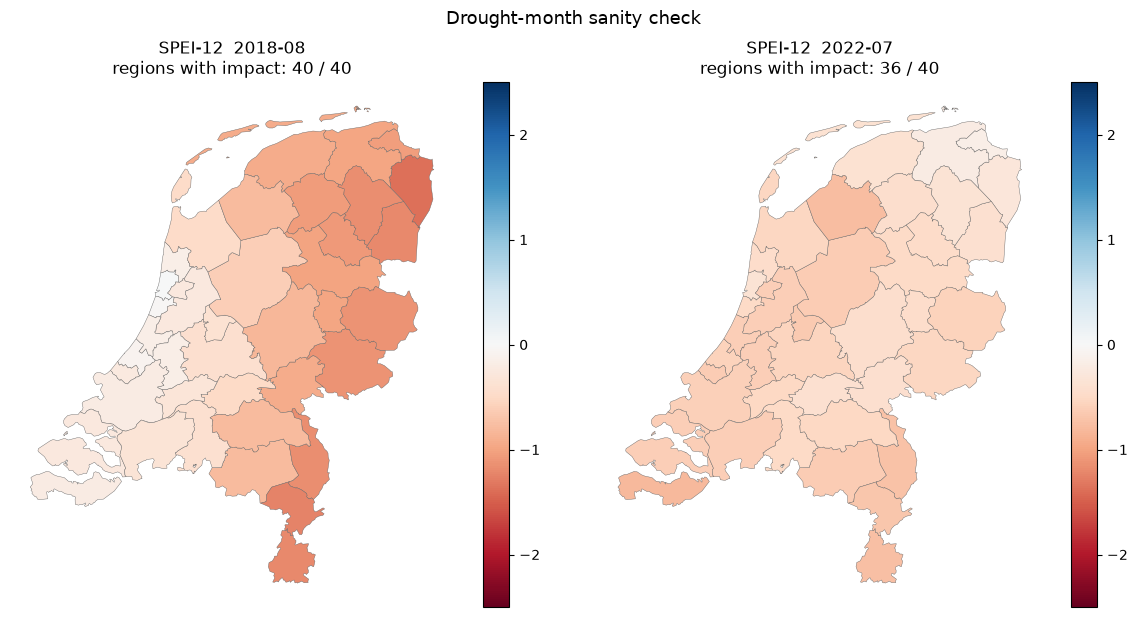

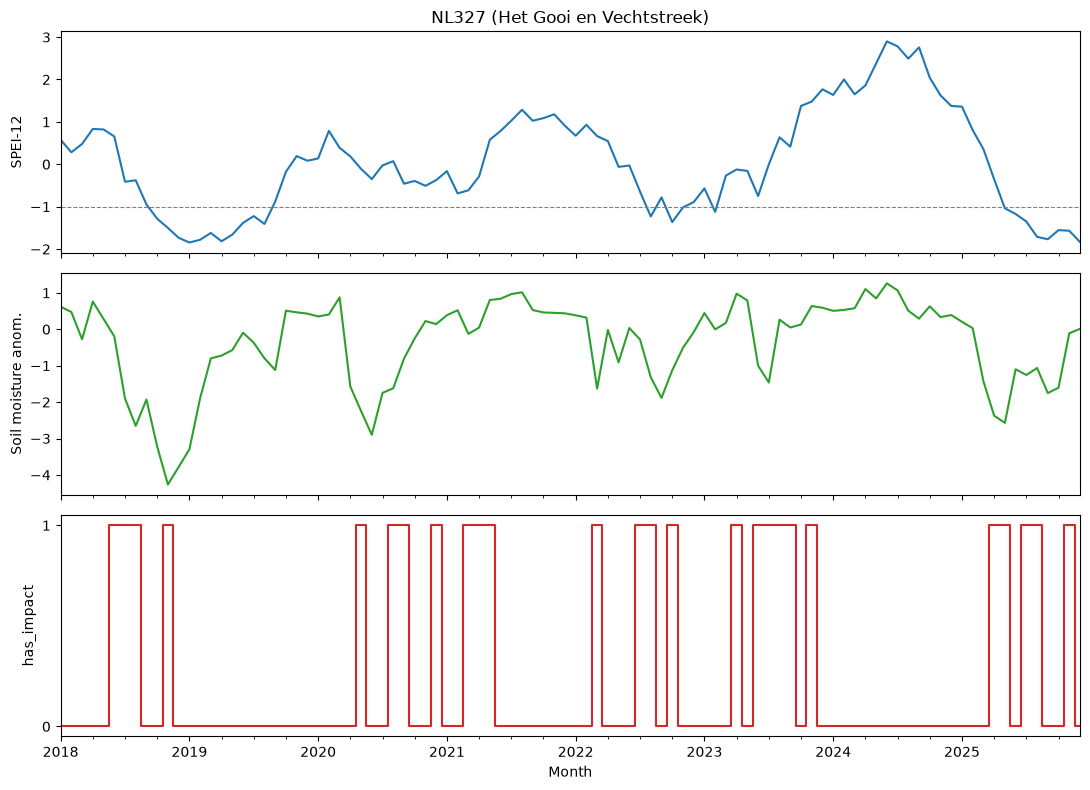

QA figures saved to Data/processed/
Done.


In [15]:
# Drought-month sanity: Aug 2018 and Jul 2022
check_months = [pd.Timestamp("2018-08-01"), pd.Timestamp("2022-07-01")]
map_base = nuts3.merge(
    meteo_panel[["nuts3_id", "year_month", "spei_12", "soil_moisture_anom"]],
    on="nuts3_id",
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, ym in zip(axes, check_months):
    g = map_base[map_base["year_month"] == ym].copy()
    g.plot(
        column="spei_12",
        ax=ax,
        legend=True,
        cmap="RdBu",
        vmin=-2.5,
        vmax=2.5,
        edgecolor="0.4",
        linewidth=0.3,
        missing_kwds={"color": "lightgrey"},
    )
    n_imp = panel.loc[panel["year_month"] == ym, "has_impact"].sum()
    ax.set_title(f"SPEI-12  {ym:%Y-%m}\nregions with impact: {int(n_imp)} / 40")
    ax.set_axis_off()
plt.suptitle("Drought-month sanity check", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "qa_drought_month_spei12.png", dpi=150, bbox_inches="tight")
plt.show()

# Example region time series
example_id = "NL327"
ex = panel[panel["nuts3_id"] == example_id].sort_values("year_month").copy()
ex["has_impact"] = ex["has_impact"].astype(float)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
ex.plot(x="year_month", y="spei_12", ax=axes[0], legend=False, color="tab:blue")
axes[0].axhline(-1, color="grey", ls="--", lw=0.8)
axes[0].set_ylabel("SPEI-12")
axes[0].set_title(f"{example_id} ({ex['nuts3_name'].iloc[0]})")
ex.plot(x="year_month", y="soil_moisture_anom", ax=axes[1], legend=False, color="tab:green")
axes[1].set_ylabel("Soil moisture anom.")
# Must use pandas.plot here: axes.plot/step with raw datetime64 is invisible
# when sharex=True with pandas-dated axes above (unit mismatch).
ex.plot(
    x="year_month",
    y="has_impact",
    ax=axes[2],
    legend=False,
    drawstyle="steps-mid",
    color="tab:red",
    linewidth=1.5,
)
axes[2].set_ylabel("has_impact")
axes[2].set_ylim(-0.05, 1.05)
axes[2].set_yticks([0, 1])
axes[2].set_xlabel("Month")
plt.tight_layout()
plt.savefig(OUT_DIR / "qa_example_region_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

print("QA figures saved to Data/processed/")
print("Done.")


## 7. Predictor validation — July 2024 vs July 2025

Side-by-side NUTS-3 choropleths for model predictors (inline). Set `SAVE_JULY_MAPS = True` only if you want PNG dumps; hand-in default is False.


July national means (2025 − 2024):


,feature,mean_2024_07,mean_2025_07,diff_2025_minus_2024
0,spei_01,0.4876,-0.3814,-0.8690
1,spei_03,1.6073,-0.8219,-2.4292
2,spei_06,2.2170,-2.0006,-4.2176
3,spei_09,2.8089,-1.4850,-4.2939
4,spei_12,2.8155,-1.1317,-3.9472
5,spei_24,1.8725,1.3028,-0.5698
6,spi_01,0.5992,0.0721,-0.5271
7,spi_03,1.8253,-0.2502,-2.0755
8,spi_06,2.6178,-1.6556,-4.2734
9,spi_09,3.0742,-1.1267,-4.2009



Static features identical across months (24 cols): True
month_sin/month_cos identical across years: True
year means (2024, 2025): 2024, 2025

Hydro mean shift (2025 − 2024); negative = drier / lower moisture:


,diff
feature,
spei_01,-0.869
spei_03,-2.429
spei_06,-4.218
spei_09,-4.294
spei_12,-3.947
spei_24,-0.570
spi_01,-0.527
spi_03,-2.076
spi_06,-4.273


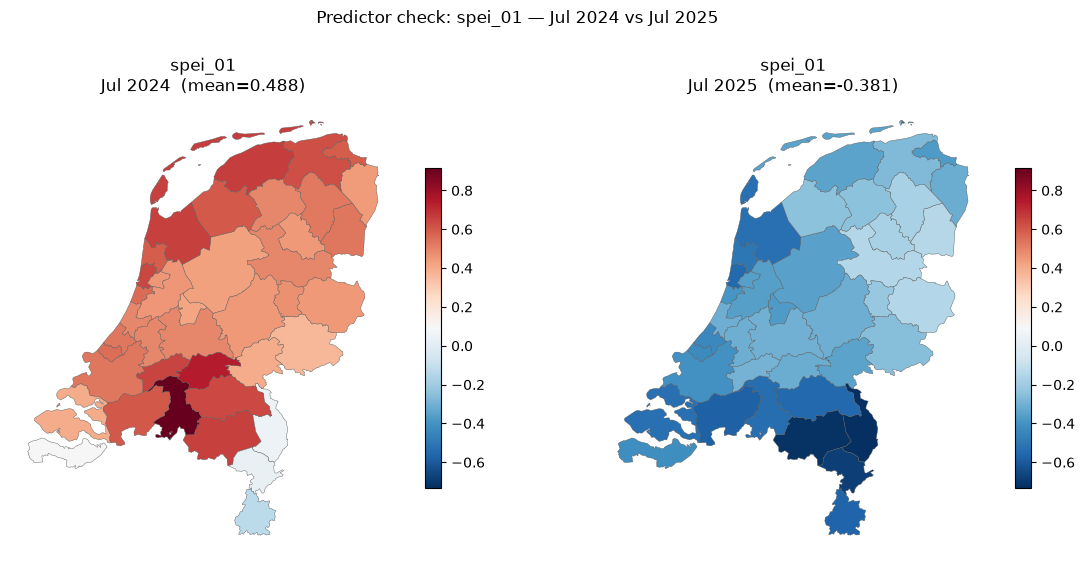

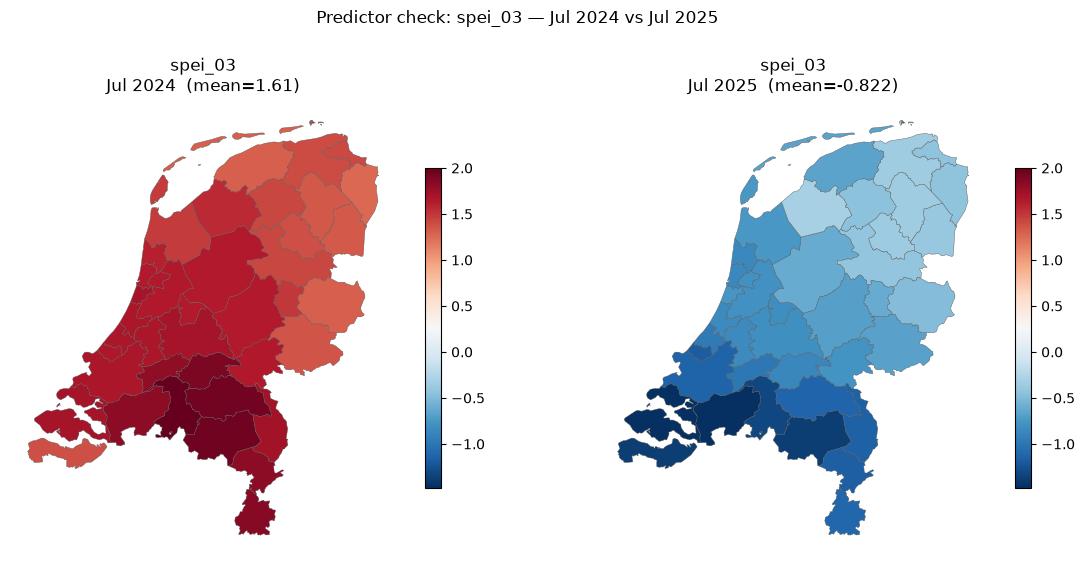

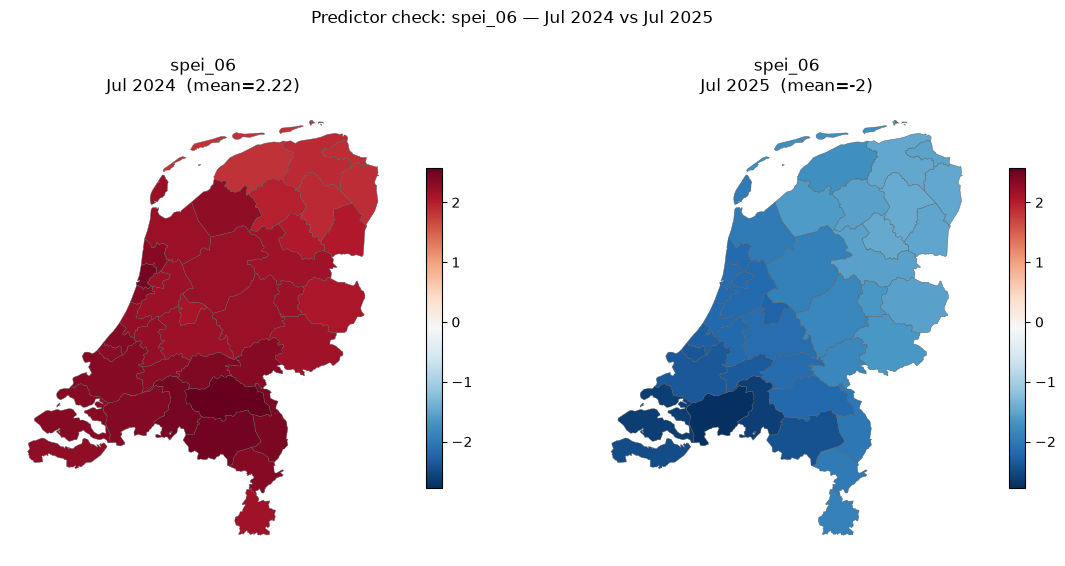

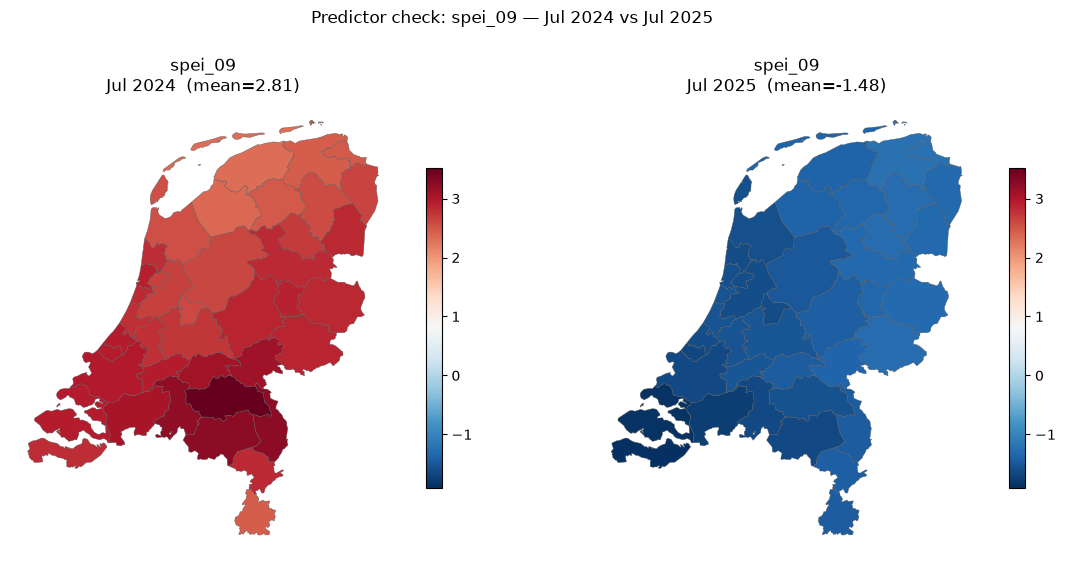

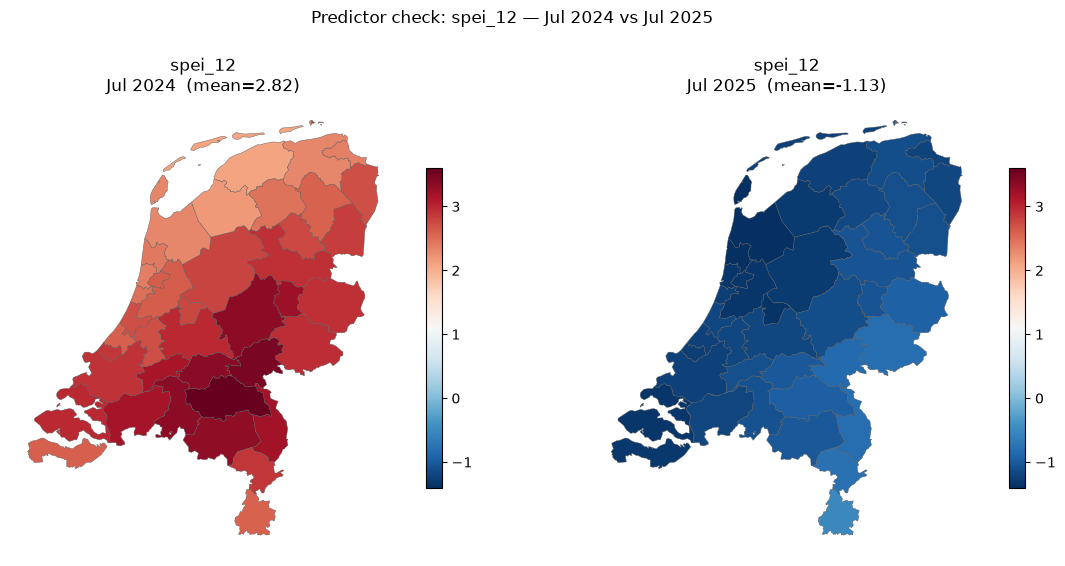

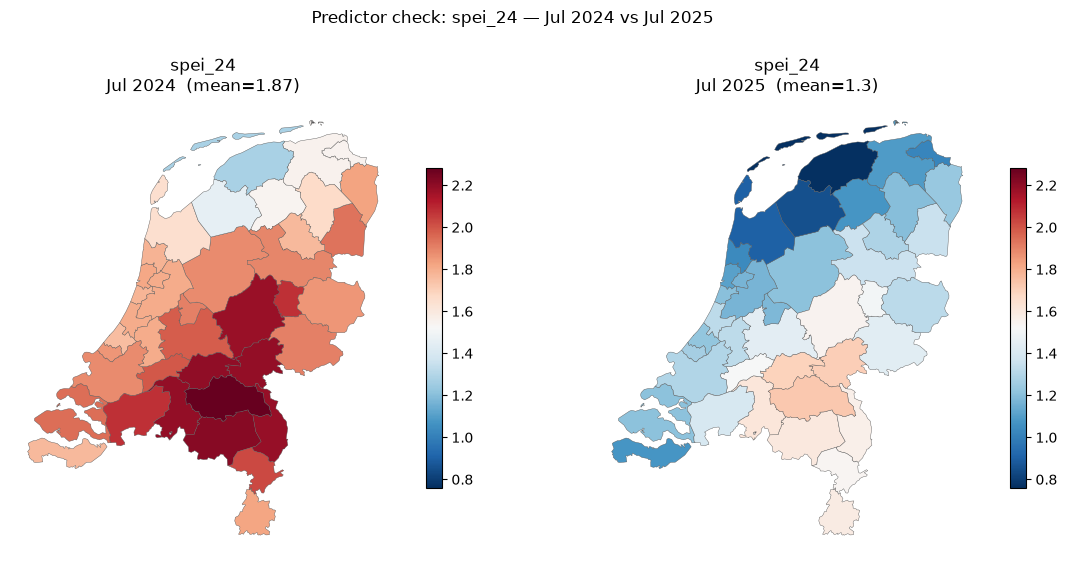

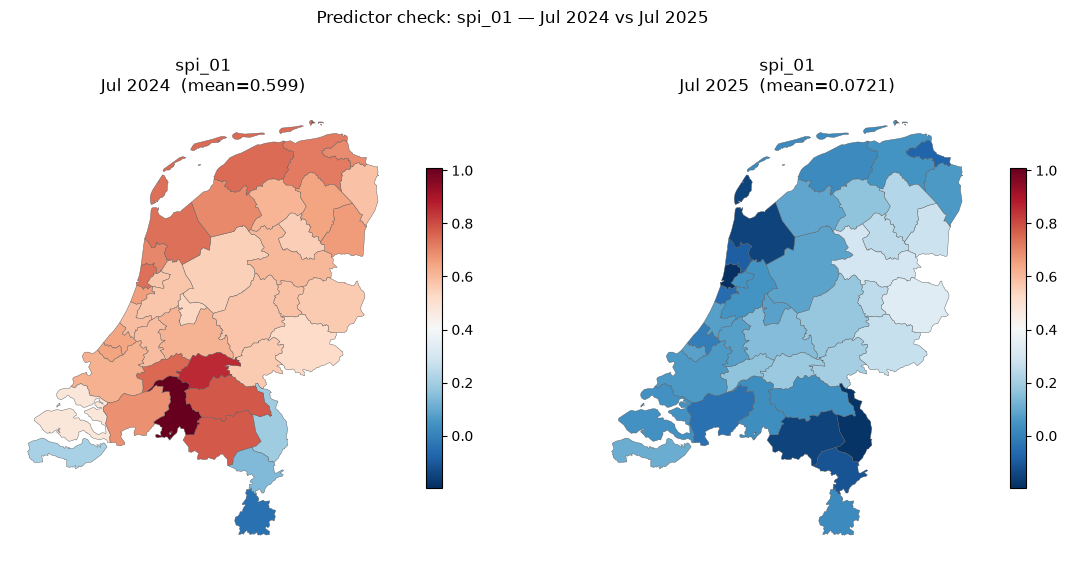

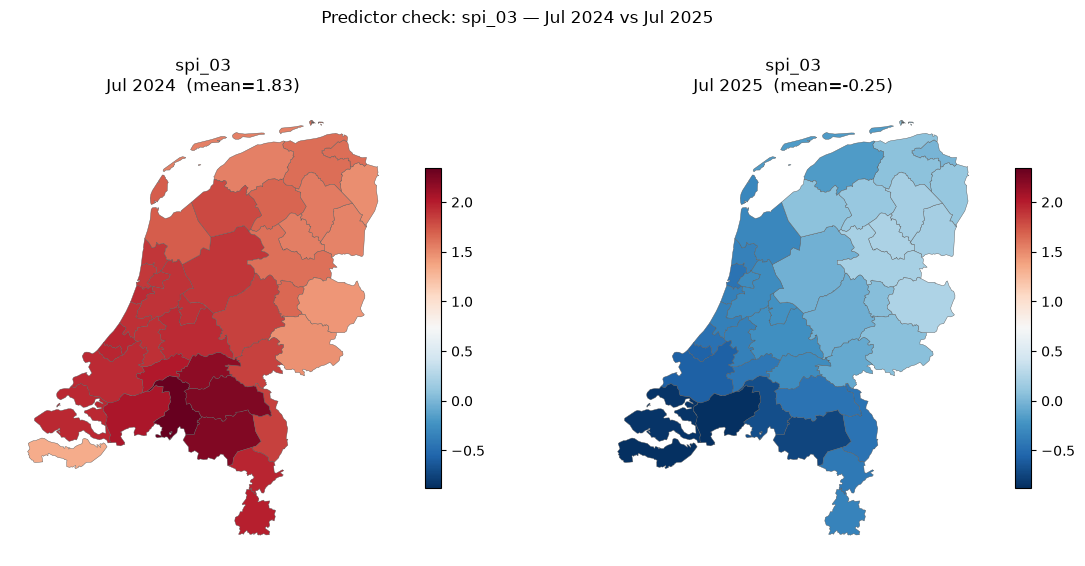

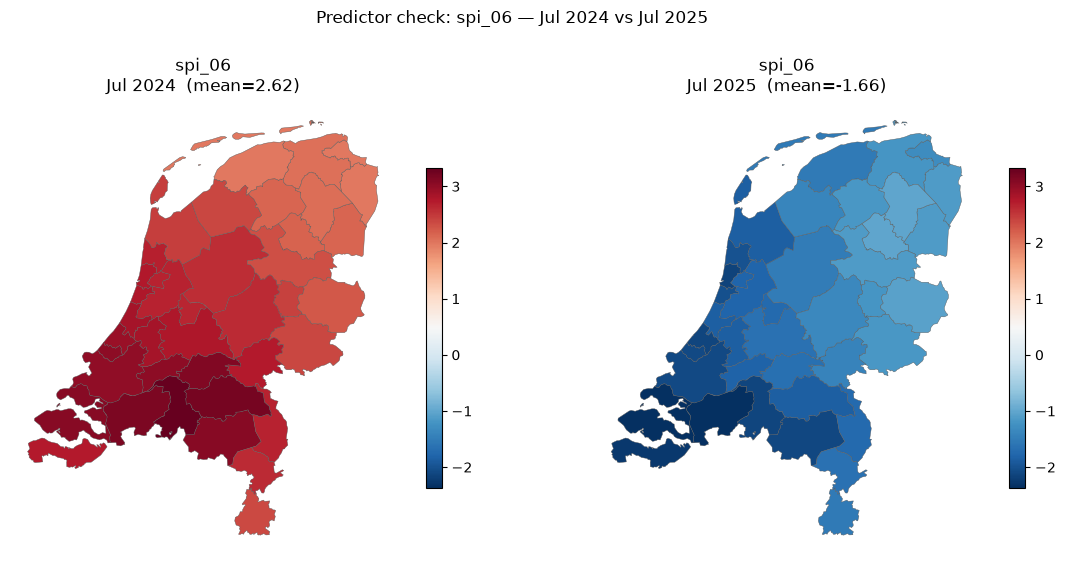

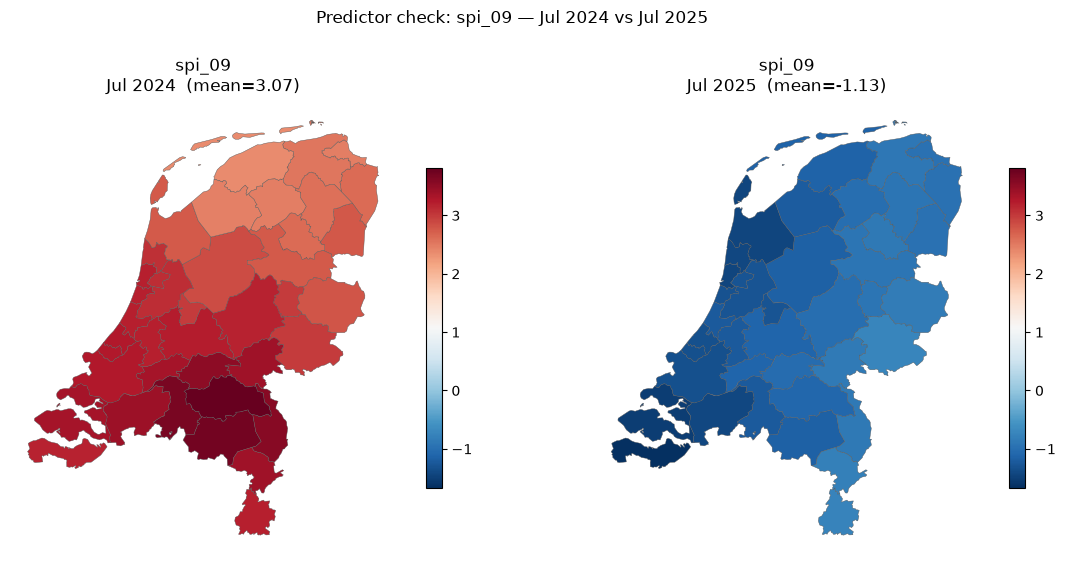

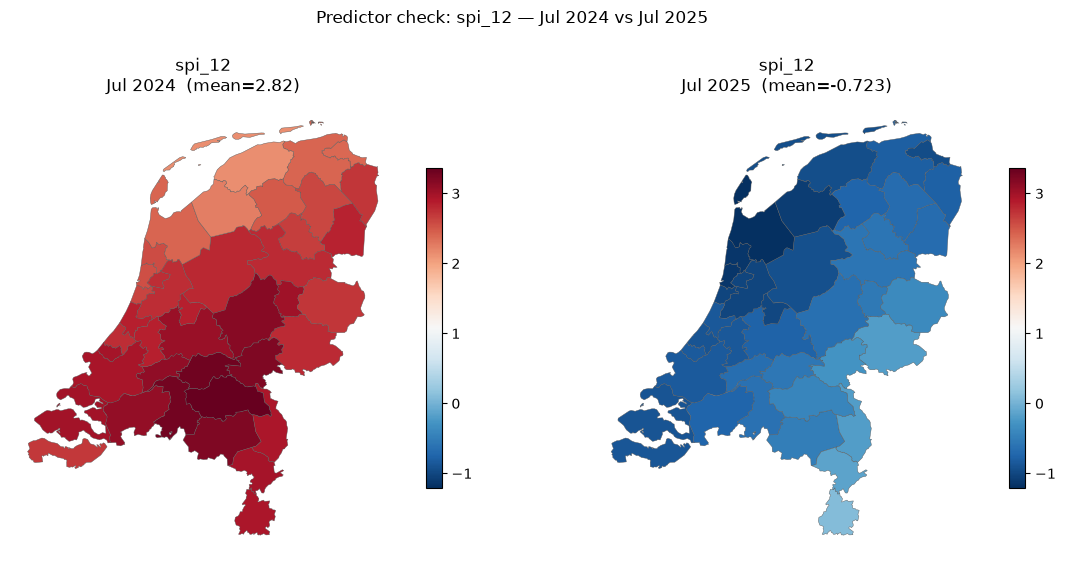

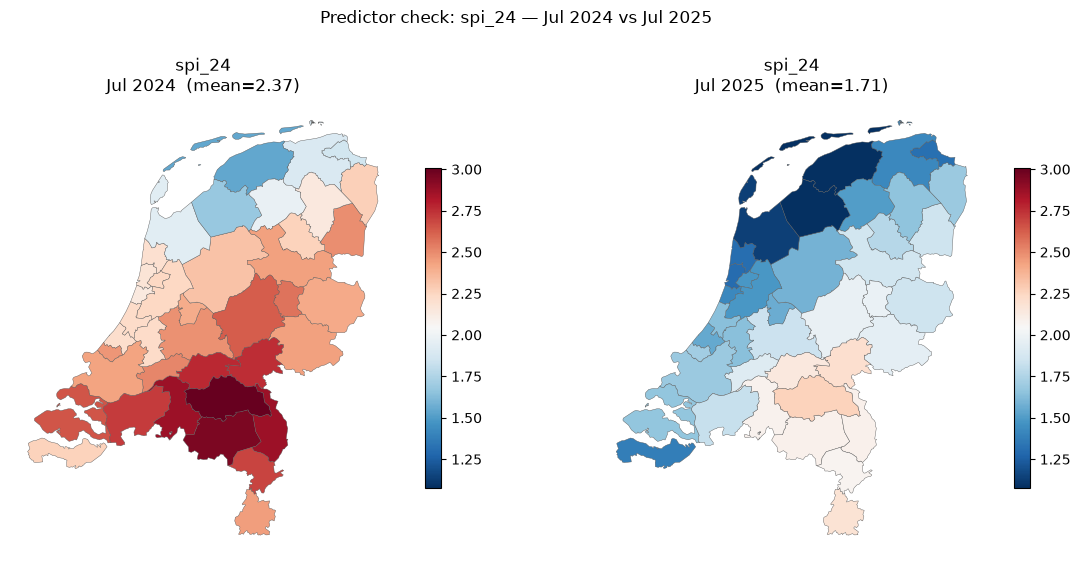

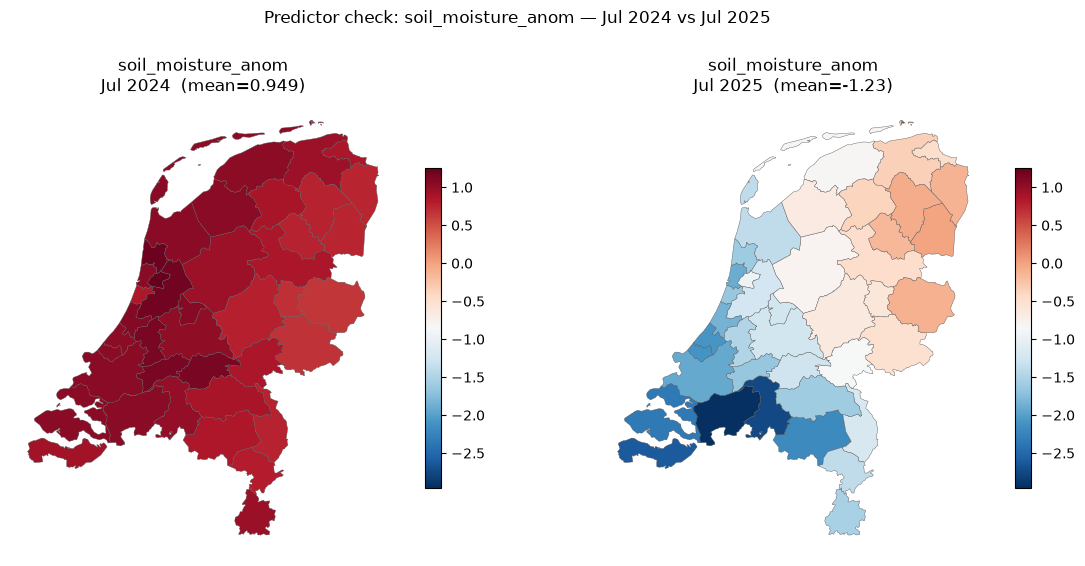

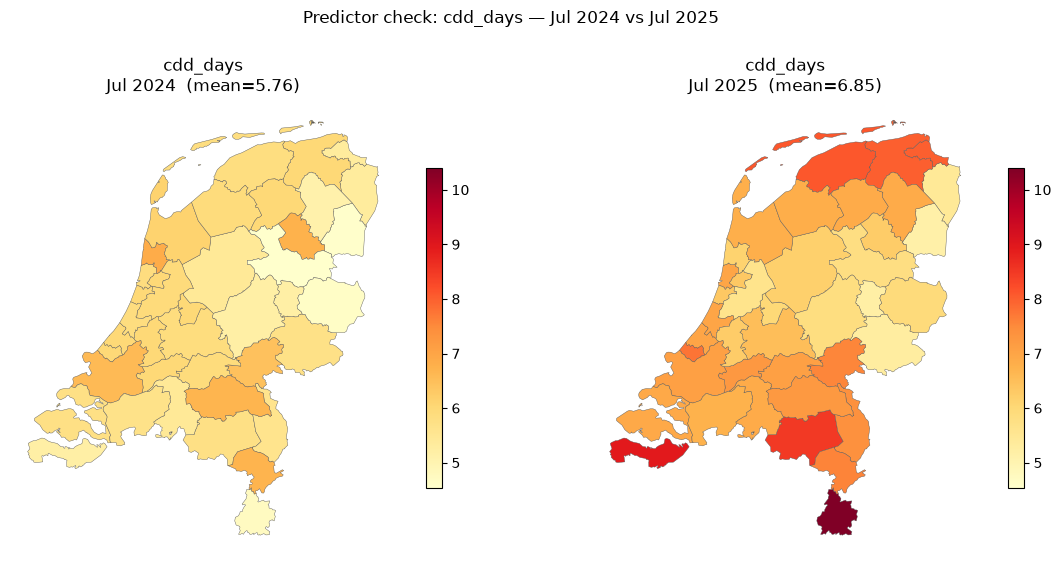

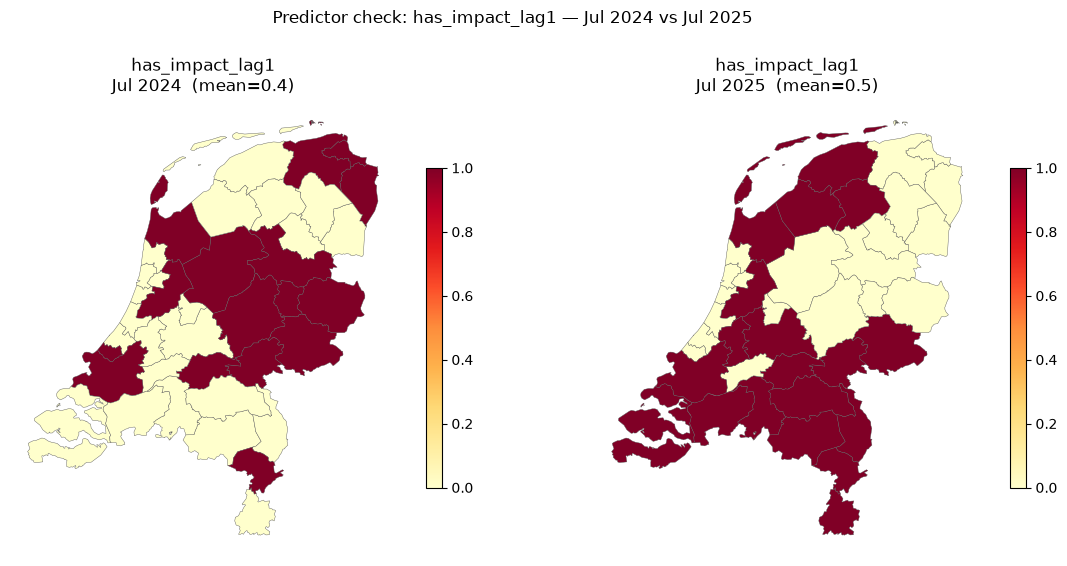

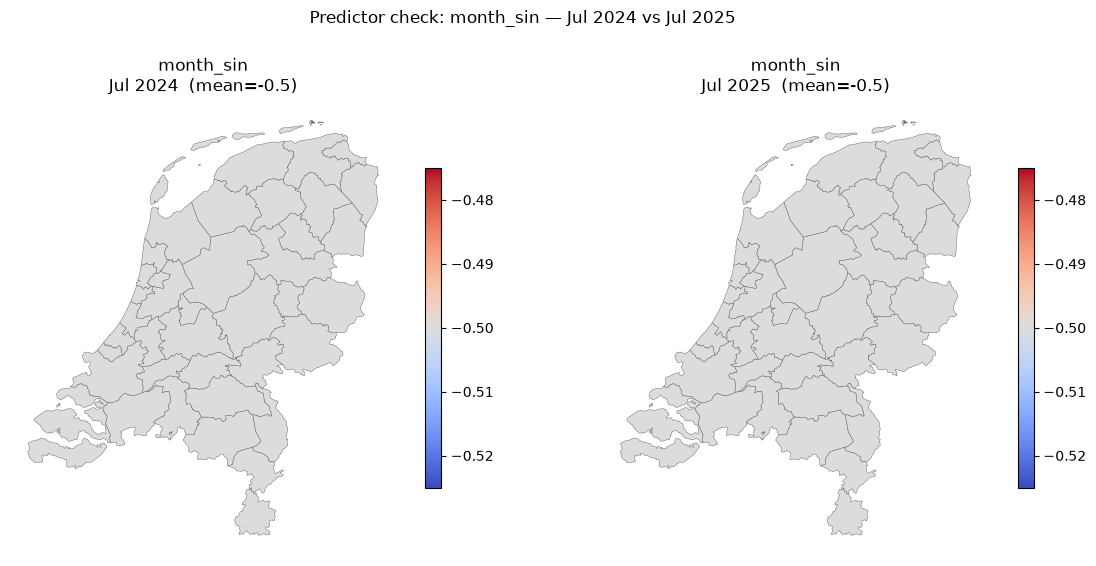

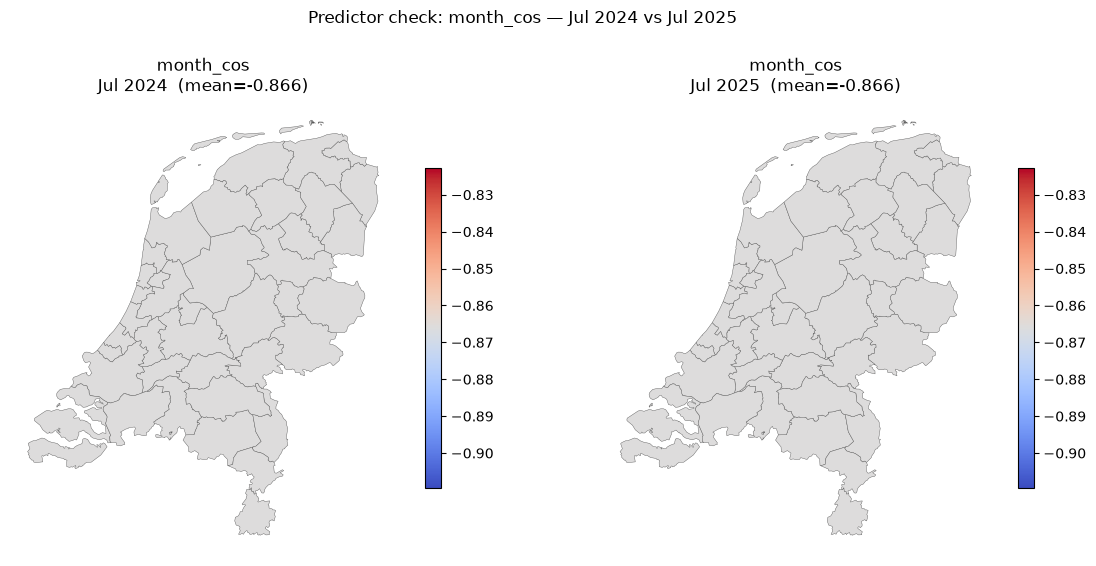

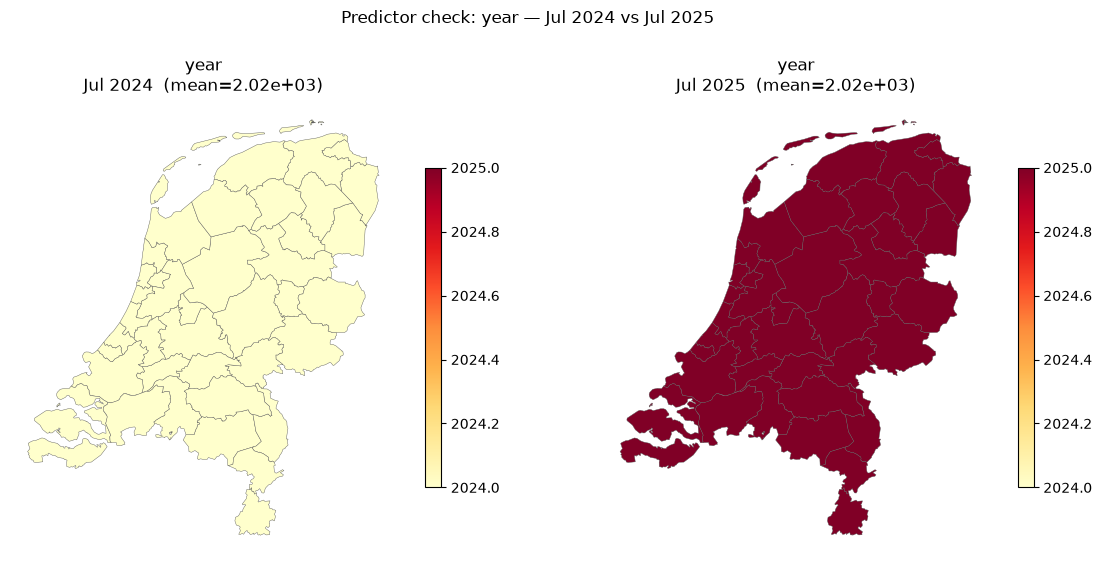

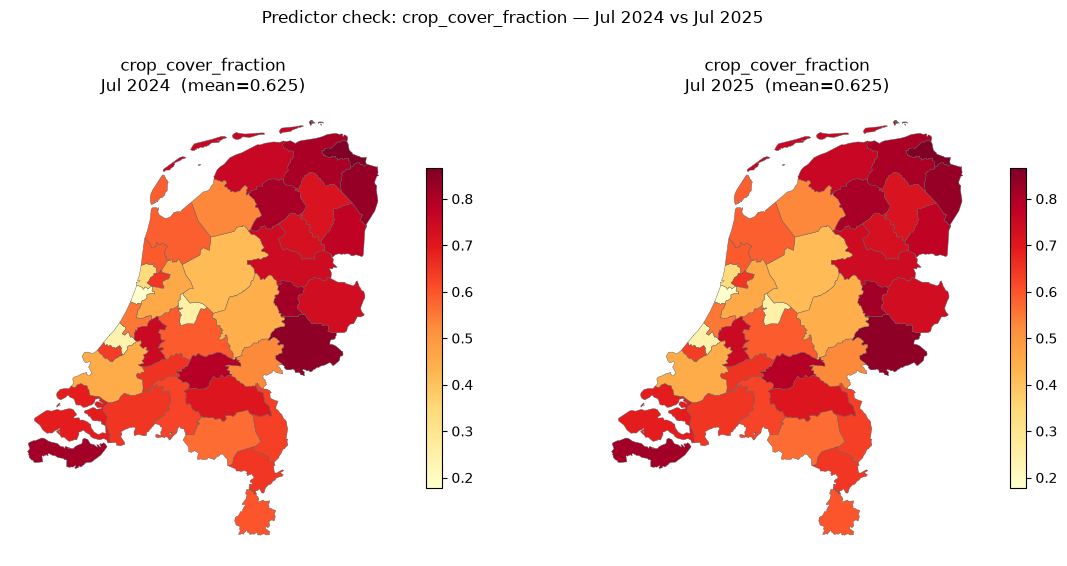

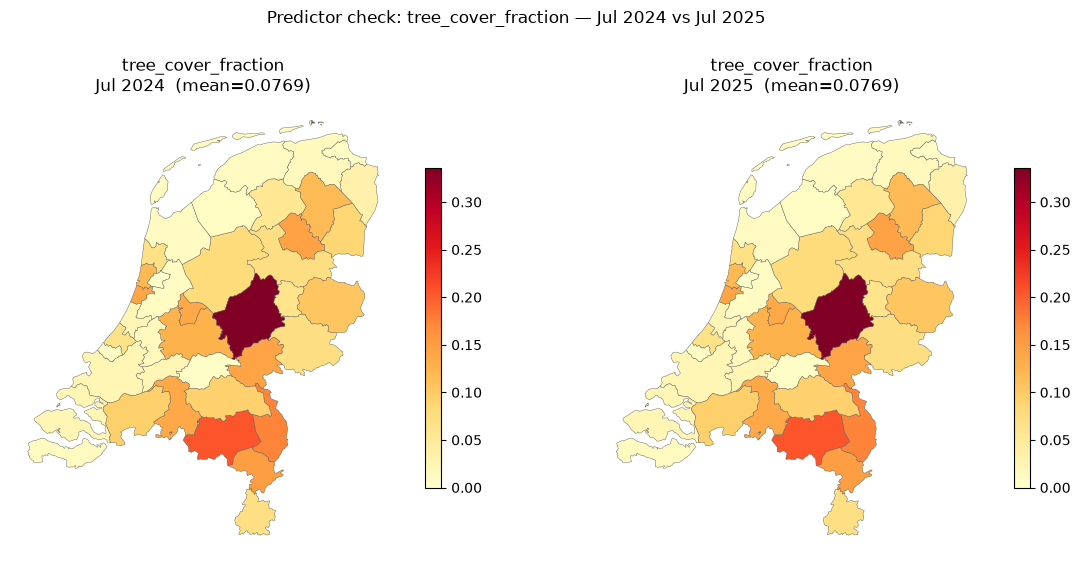

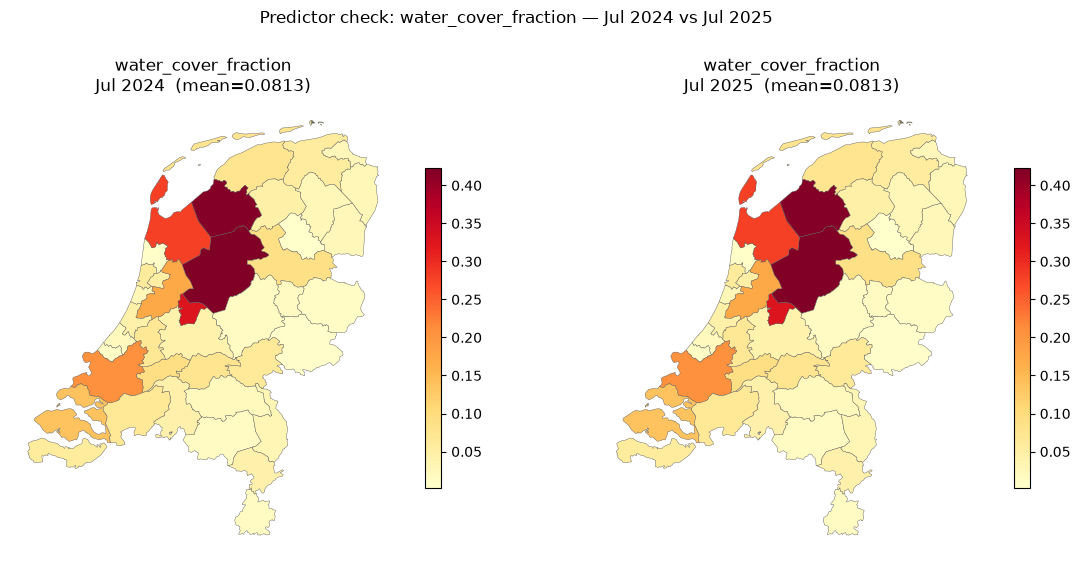

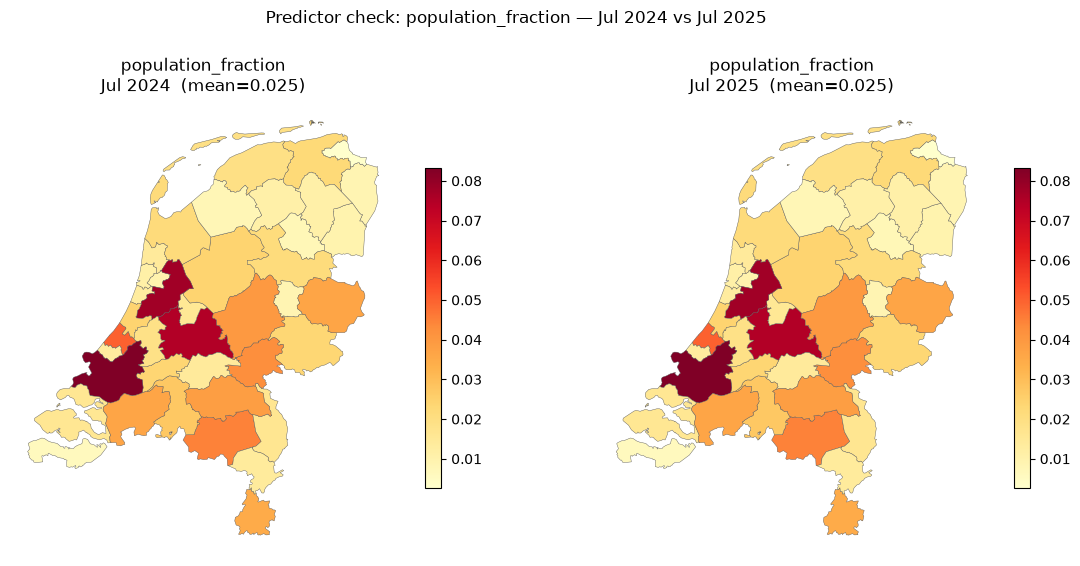

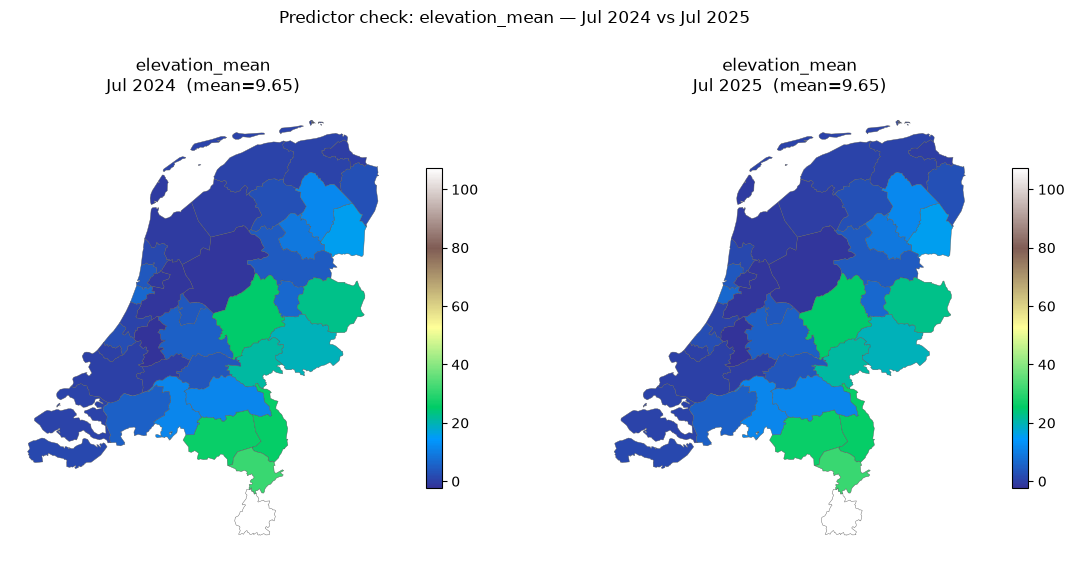

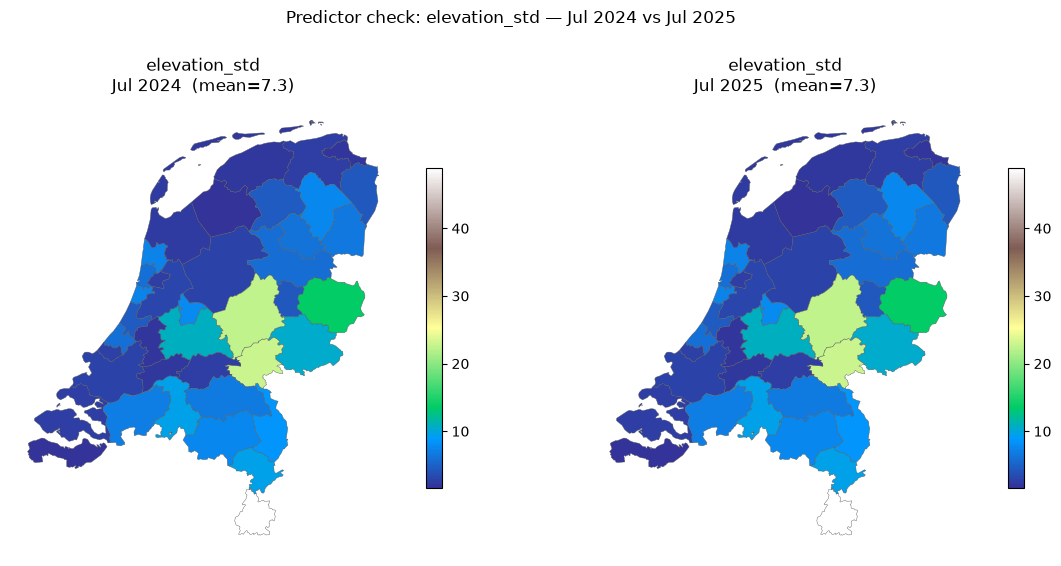

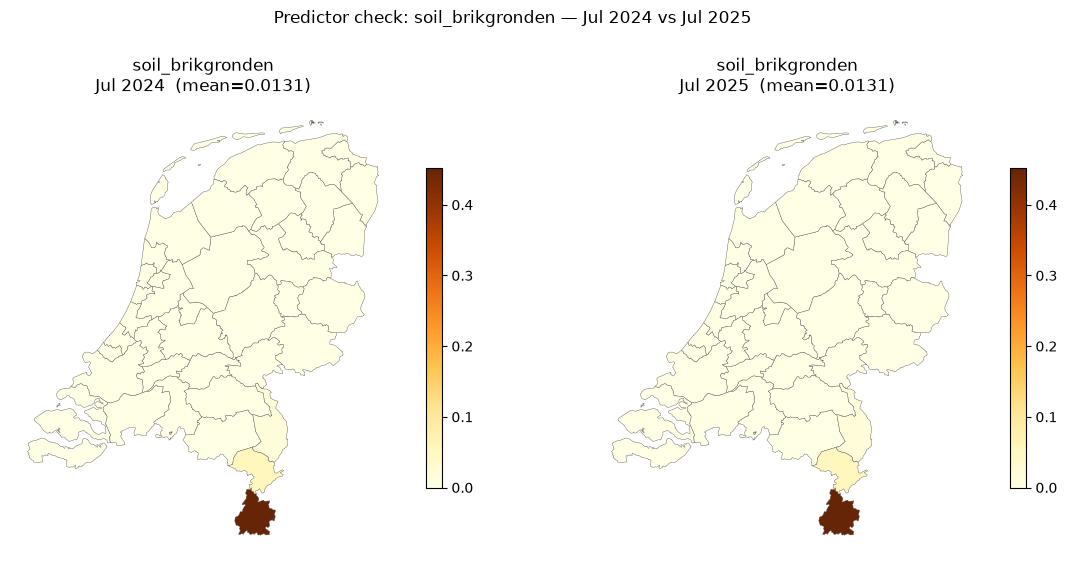

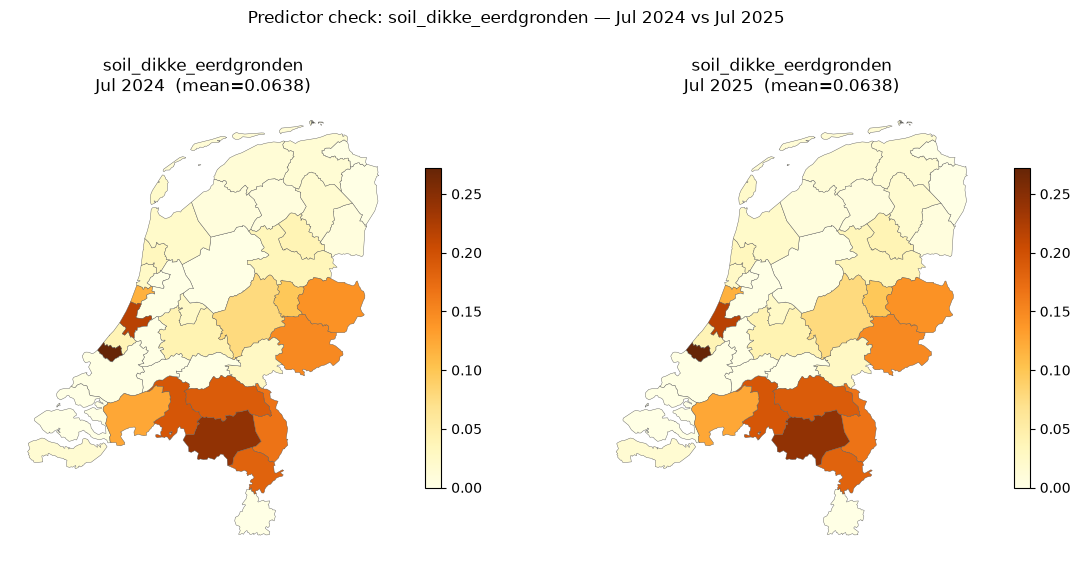

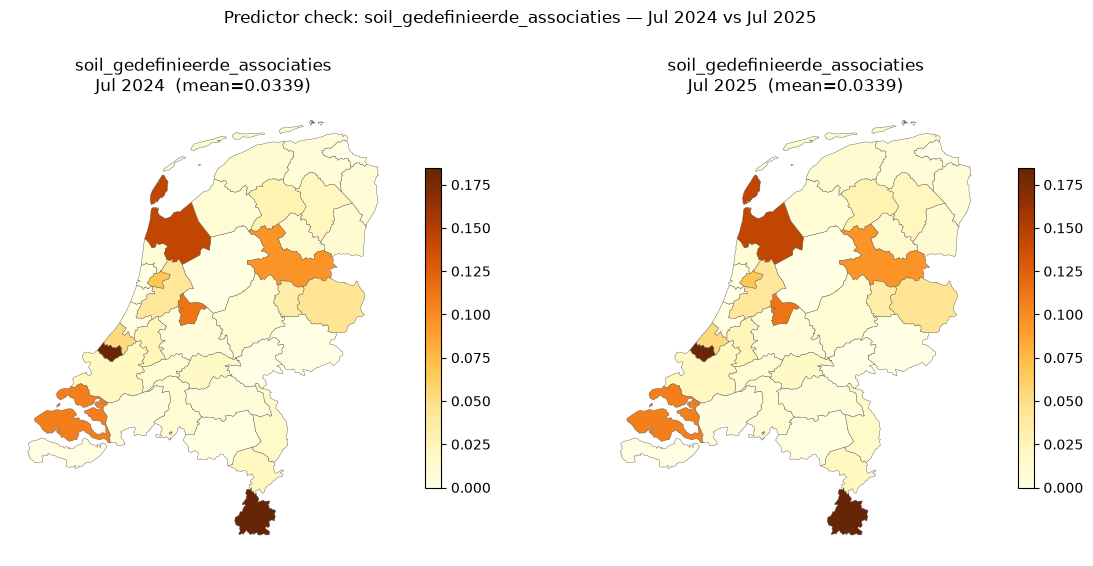

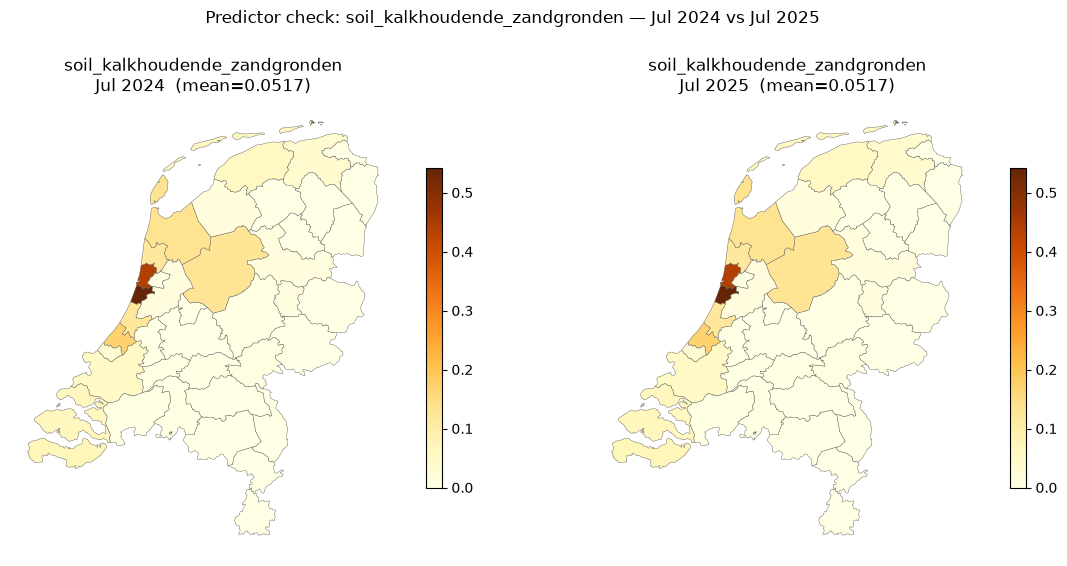

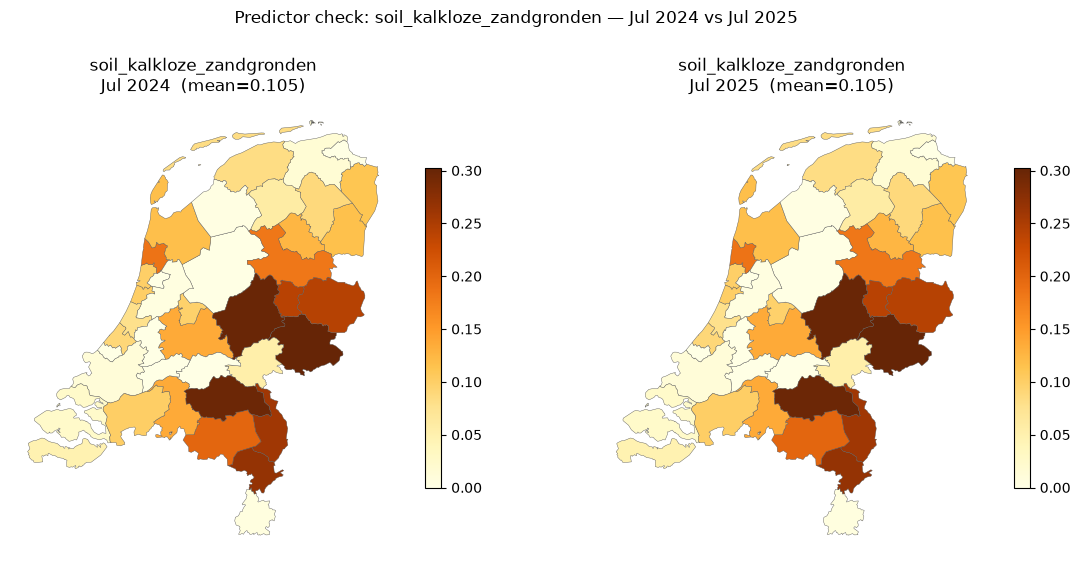

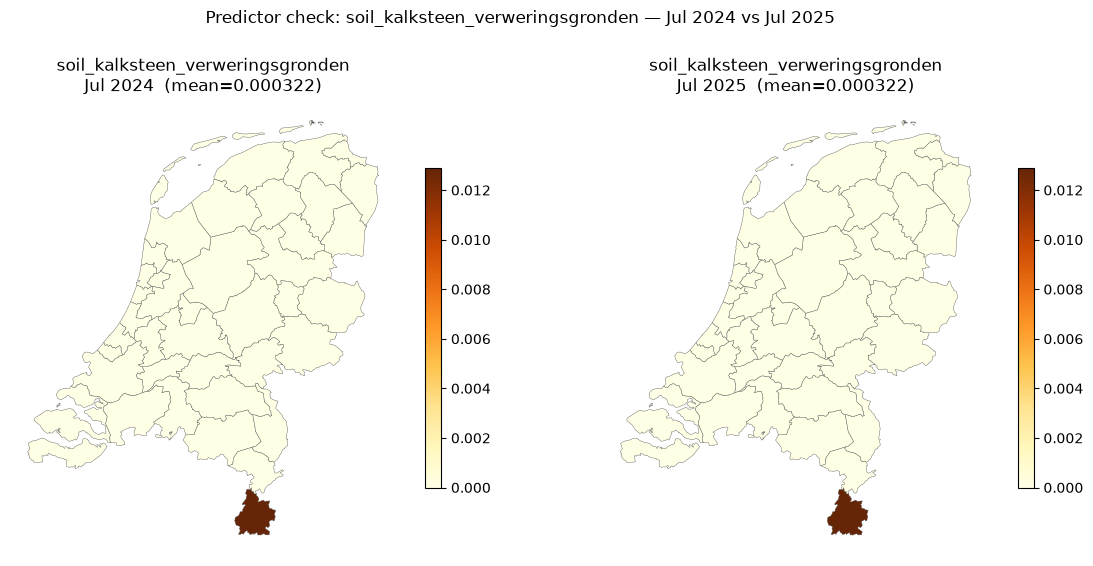

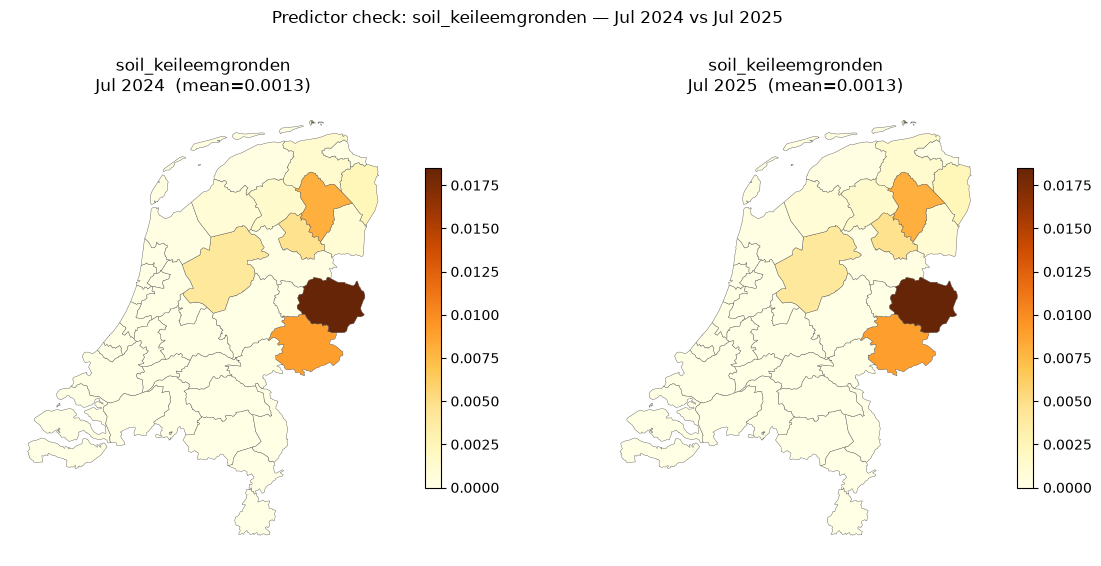

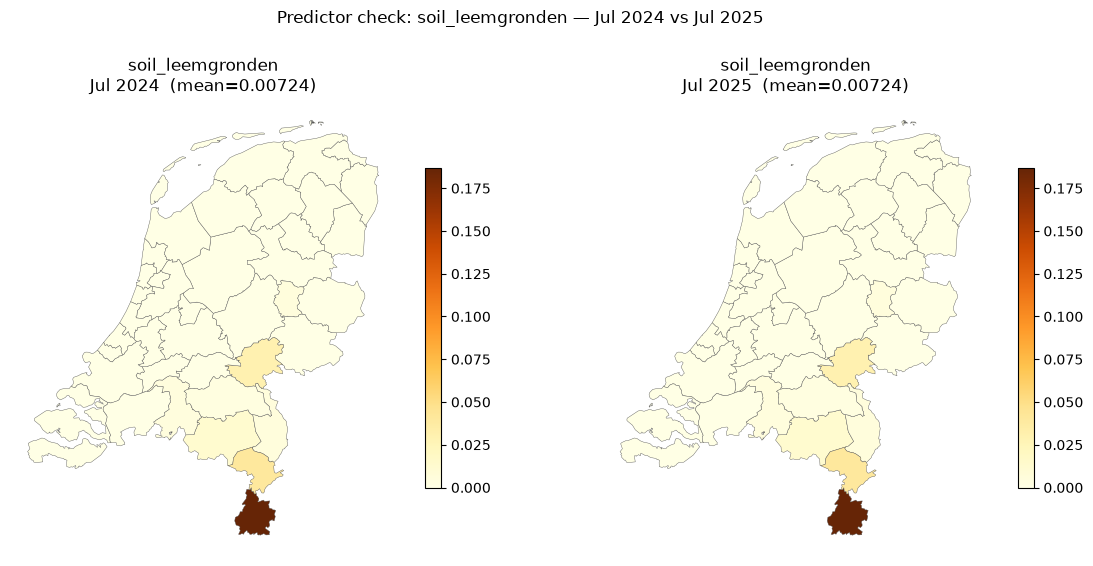

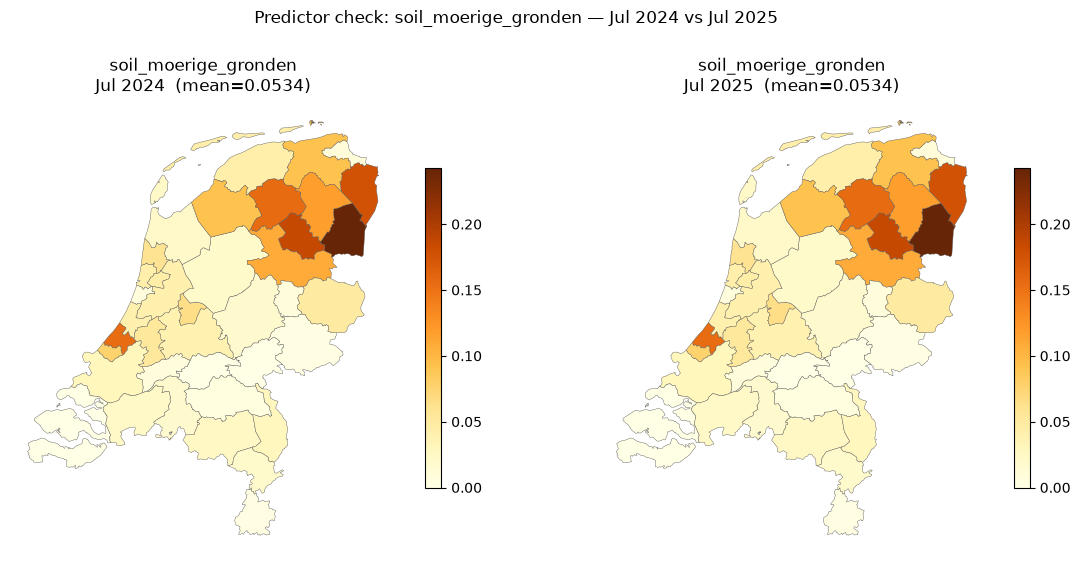

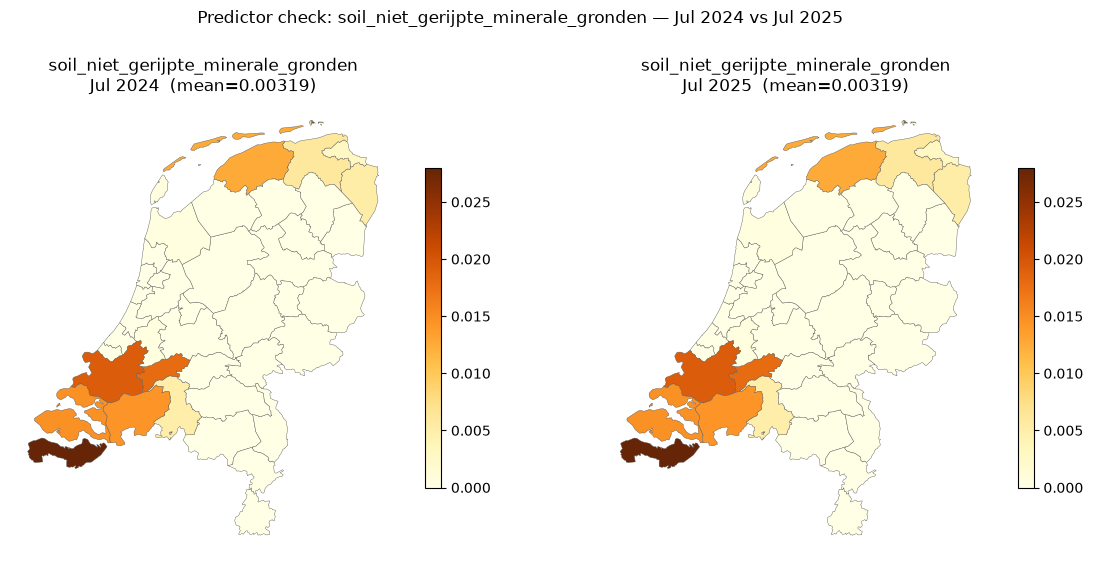

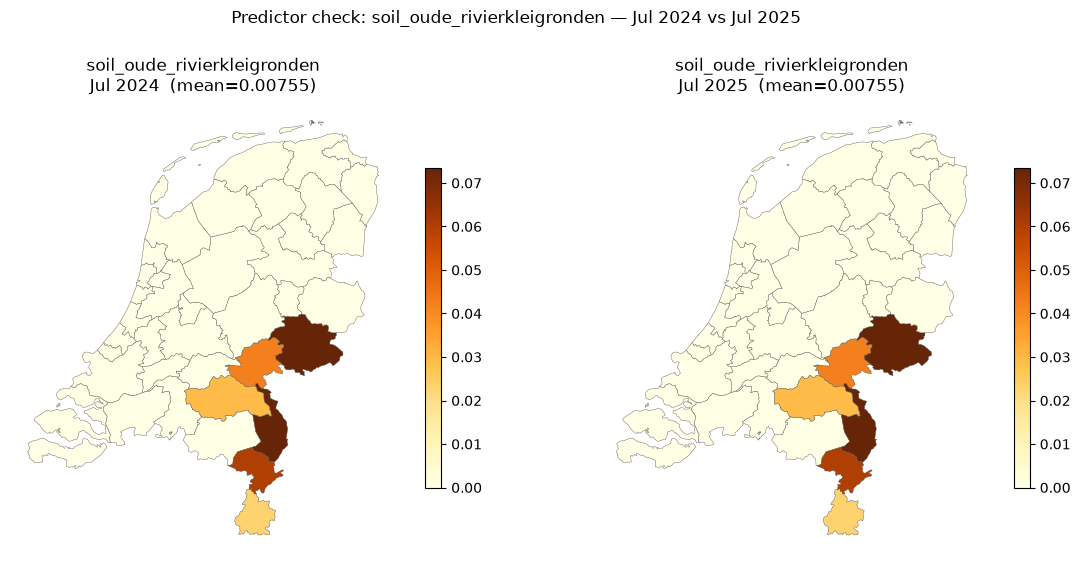

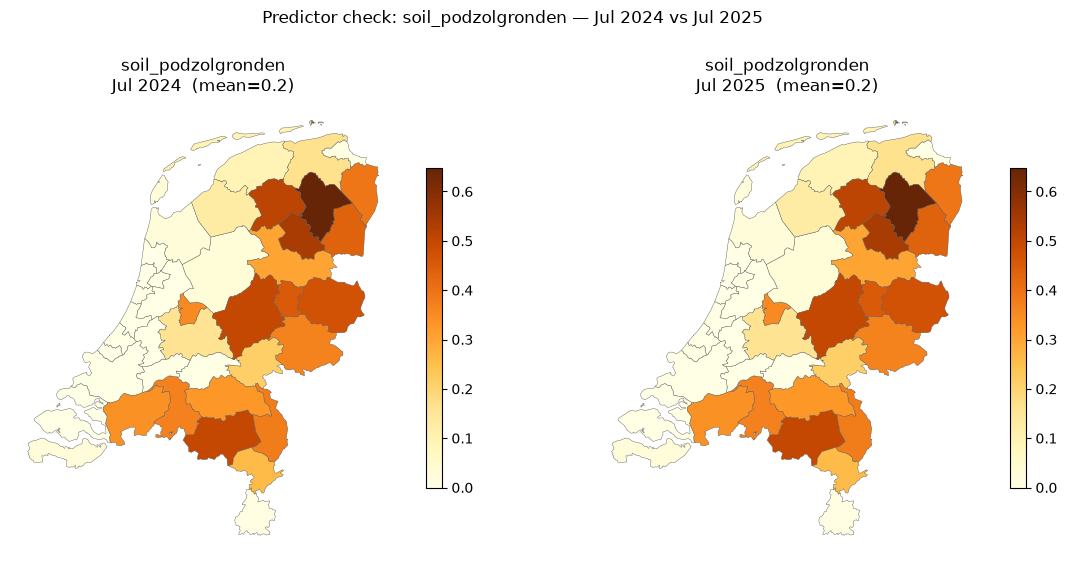

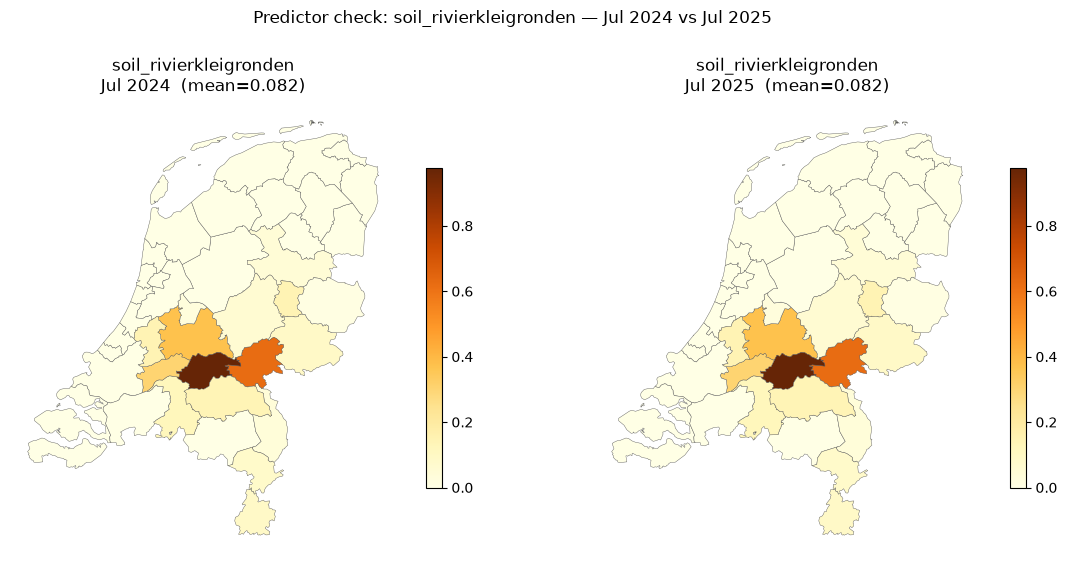

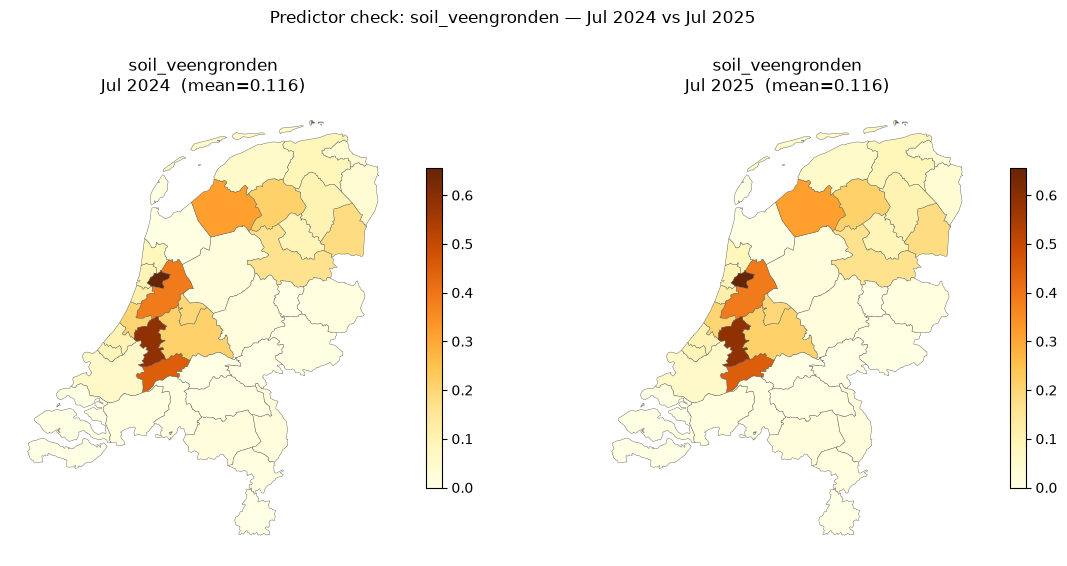

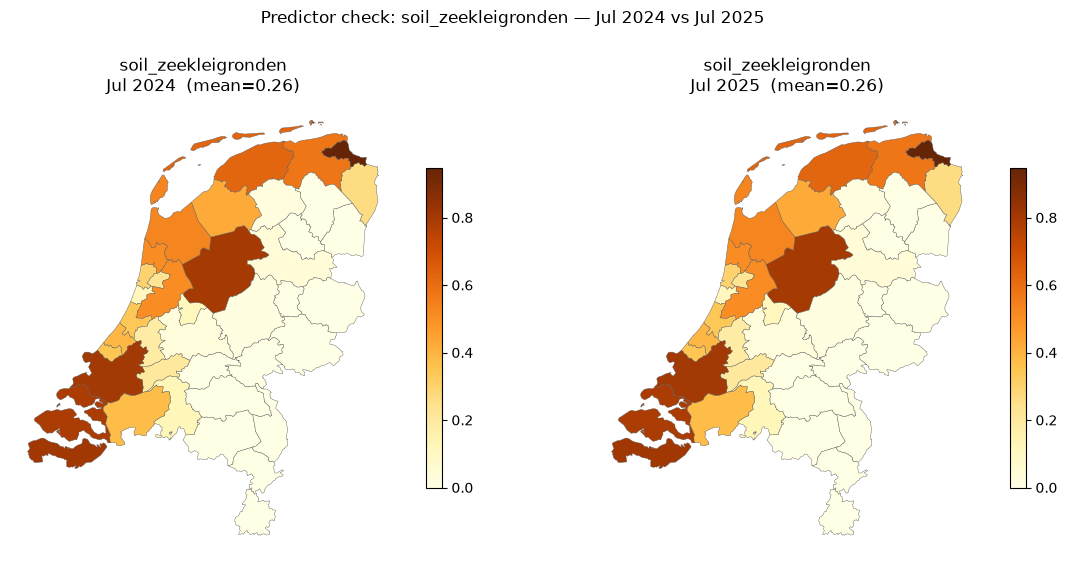

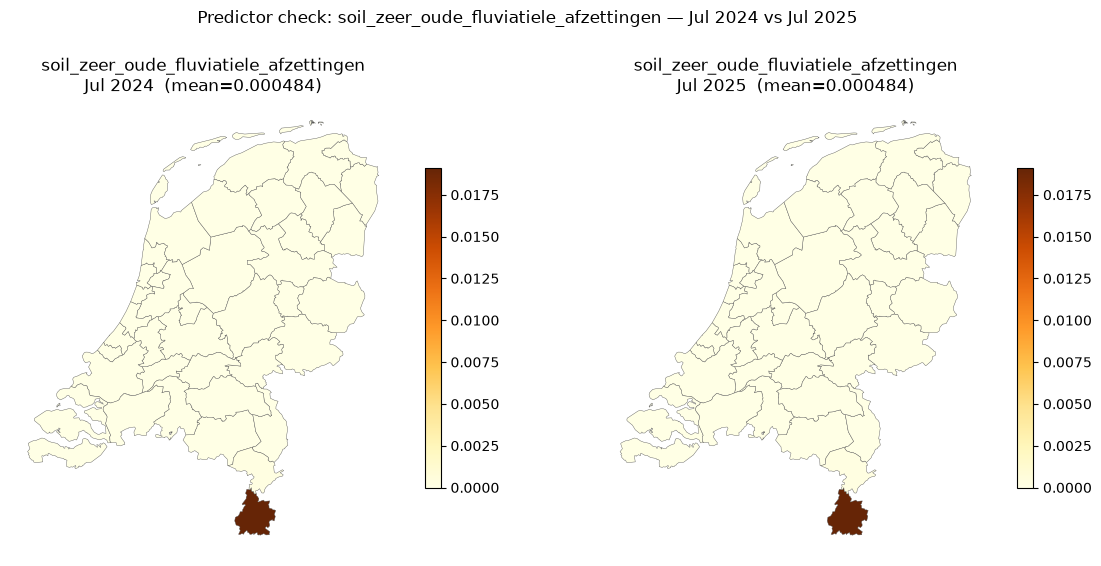

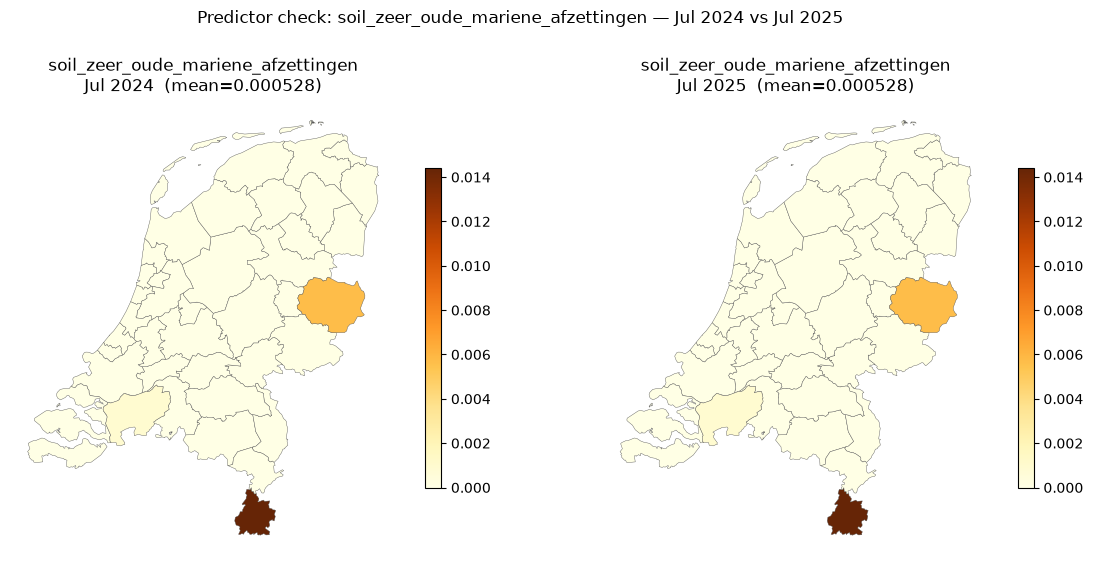

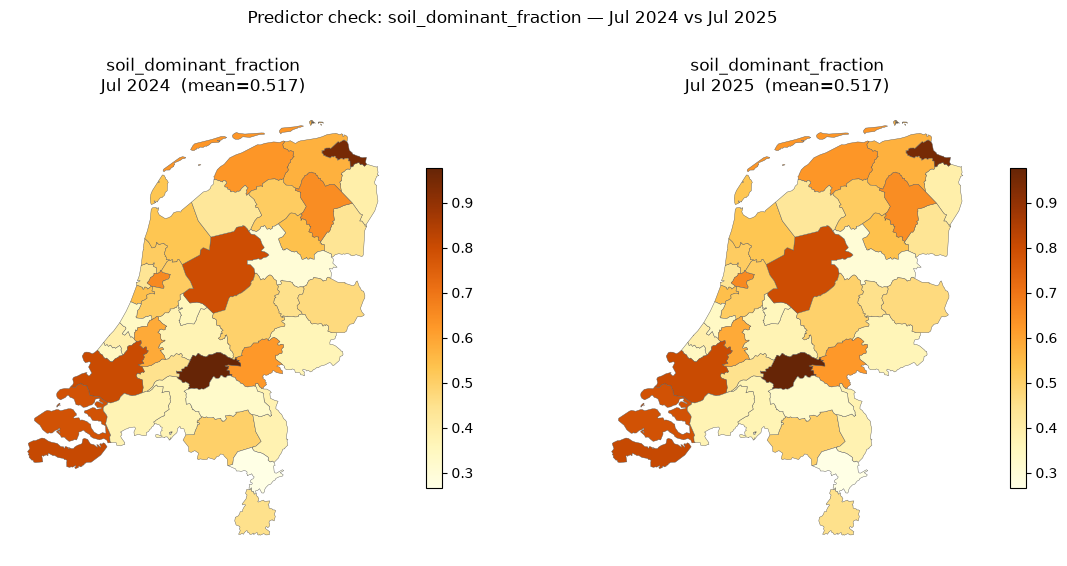

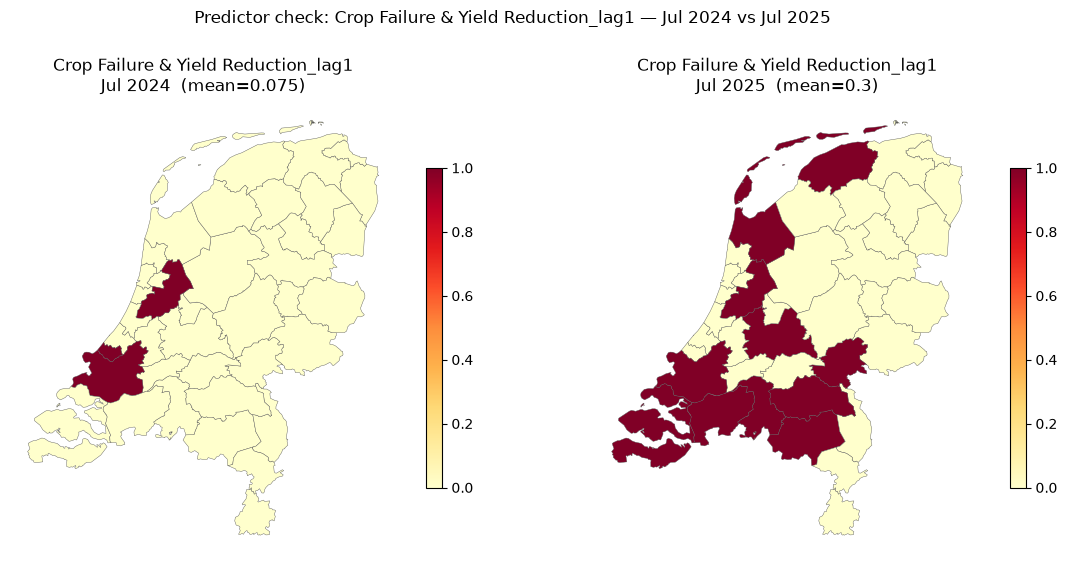

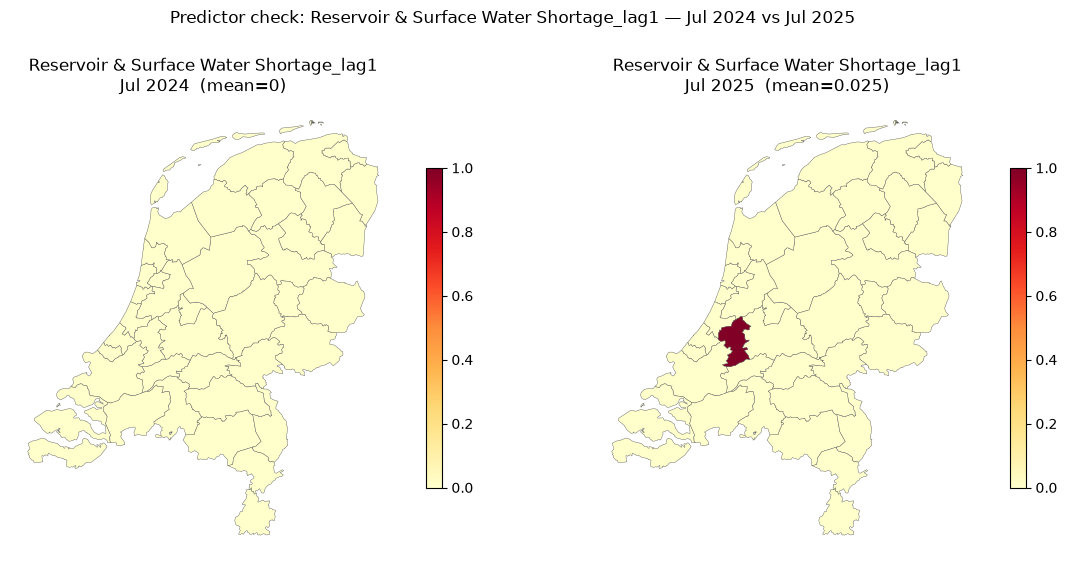

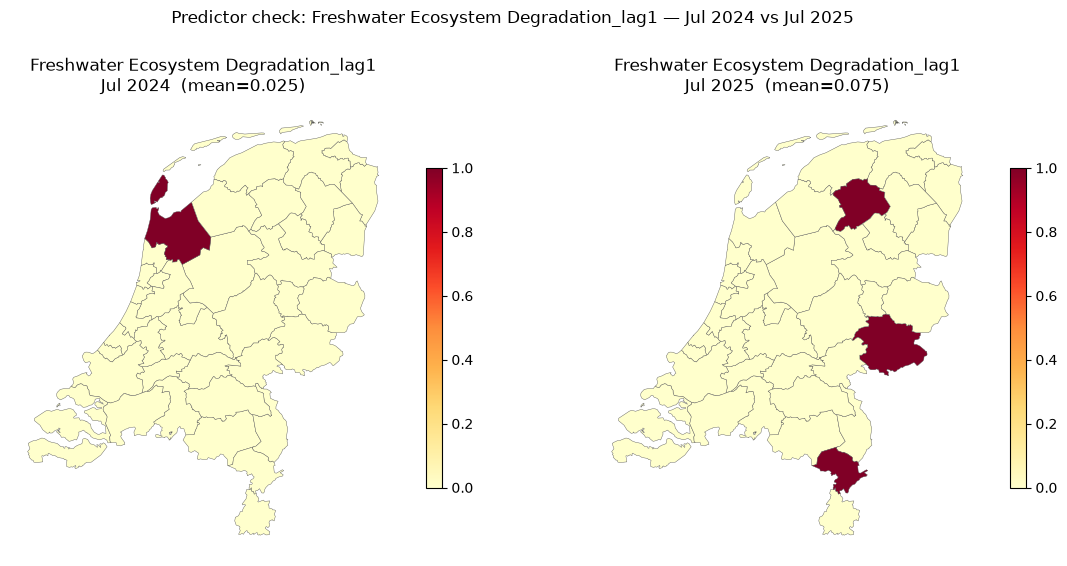

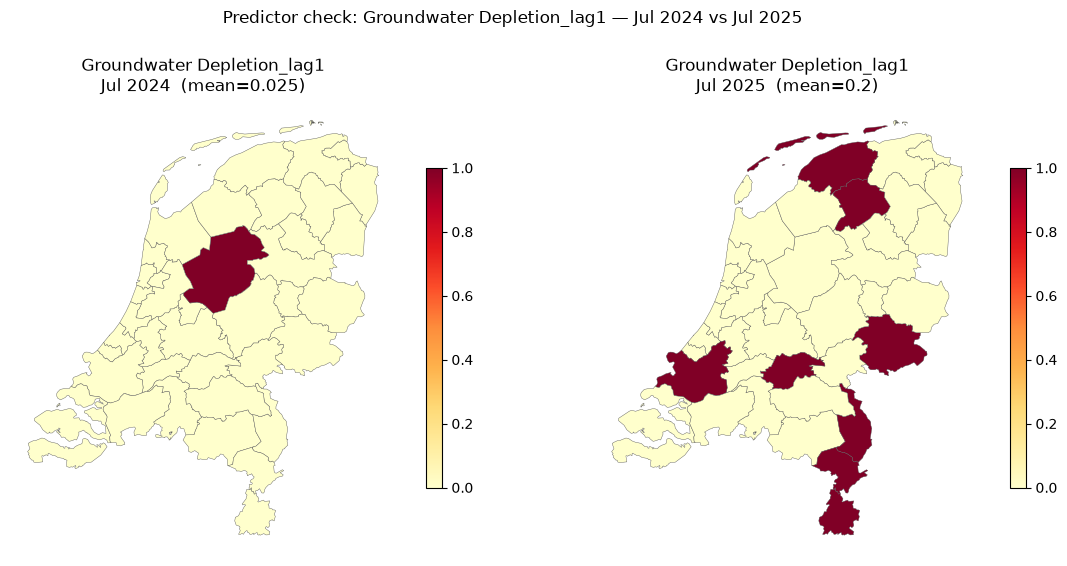

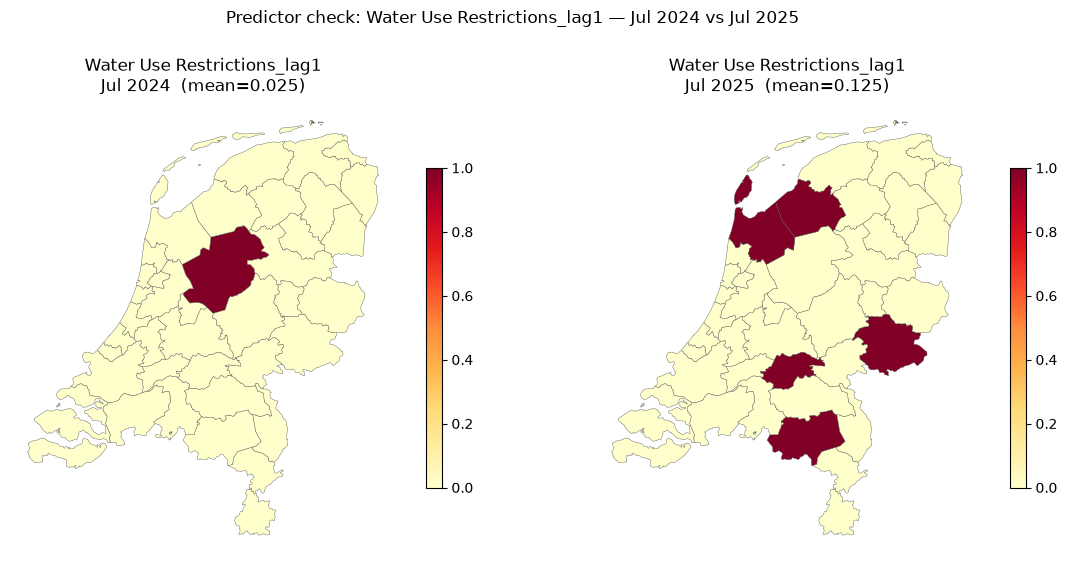

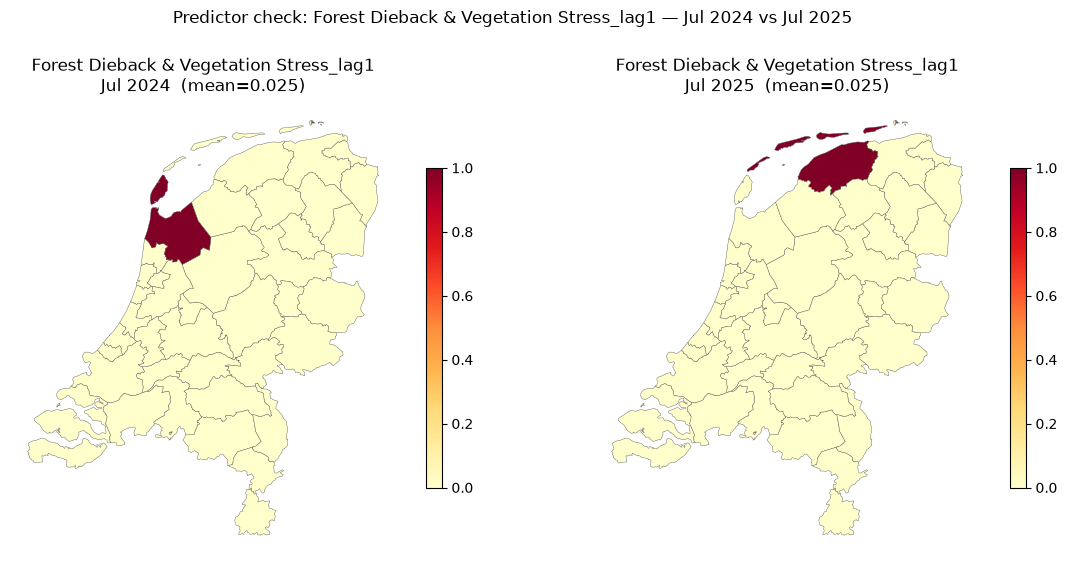

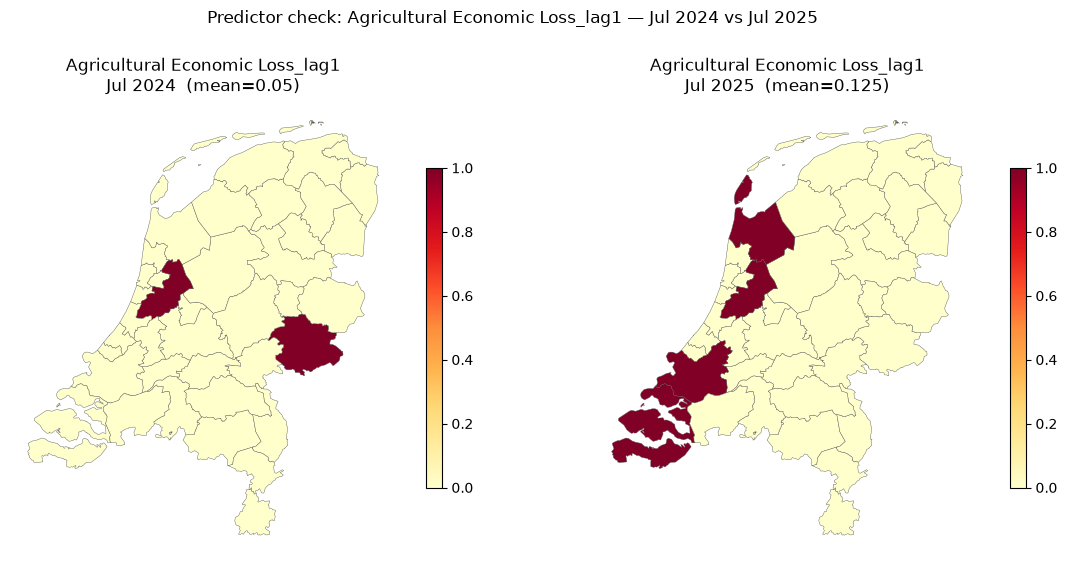

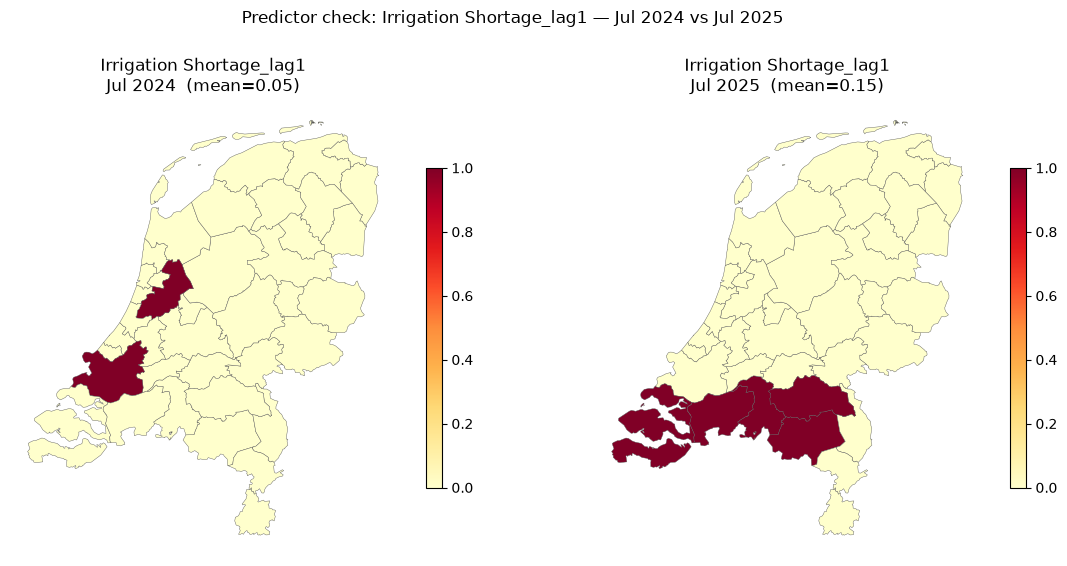

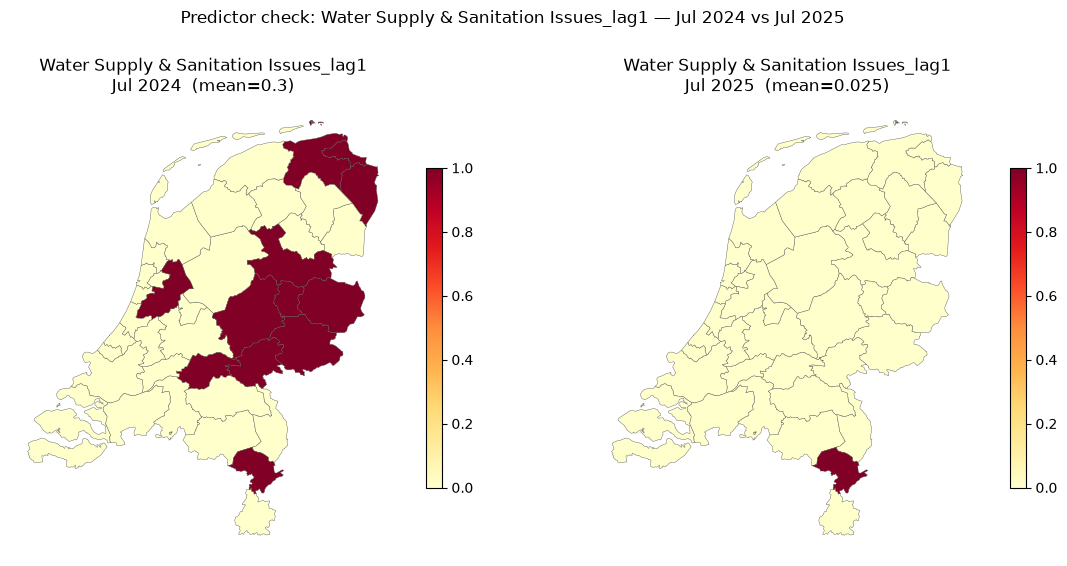

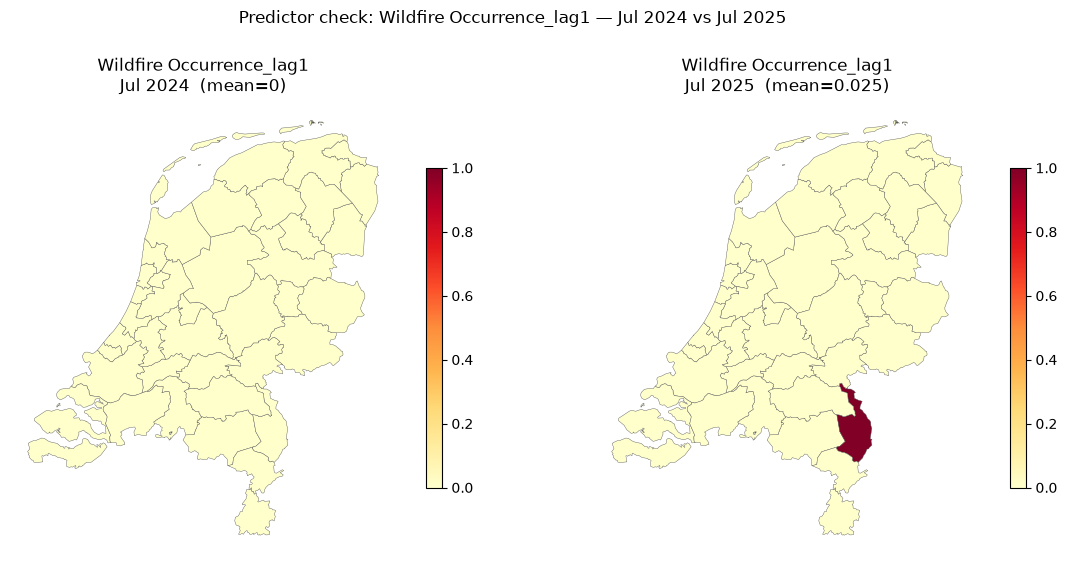


July maps: shown inline only (SAVE_JULY_MAPS=False)
Saved means table → qa_predictor_july_means.csv


In [16]:
JULY_2024 = pd.Timestamp("2024-07-01")
JULY_2025 = pd.Timestamp("2025-07-01")
SAVE_JULY_MAPS = False  # hand-in: show inline only; do not dump PNGs to disk
MAP_DIR = OUT_DIR / "qa_predictor_july_maps"

def _safe_name(col: str) -> str:
    return (
        col.lower()
        .replace(" & ", "_")
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )


def _cmap_for(col: str):
    if col.startswith(("spei_", "spi_")) or col == "soil_moisture_anom":
        return "RdBu_r"
    if col in {"month_sin", "month_cos"}:
        return "coolwarm"
    if col.startswith("elevation_"):
        return "terrain"
    if col.startswith("soil_"):
        return "YlOrBr"
    return "YlOrRd"


# Slice both months and join geometries
july = panel.loc[panel["year_month"].isin([JULY_2024, JULY_2025])].copy()
assert july["nuts3_id"].nunique() == 40
assert set(july["year_month"].unique()) == {JULY_2024, JULY_2025}

g24 = nuts3.merge(
    july.loc[july["year_month"] == JULY_2024, ["nuts3_id"] + MODEL_FEATURES],
    on="nuts3_id",
    how="left",
)
g25 = nuts3.merge(
    july.loc[july["year_month"] == JULY_2025, ["nuts3_id"] + MODEL_FEATURES],
    on="nuts3_id",
    how="left",
)

# National means summary
mean_rows = []
for col in MODEL_FEATURES:
    m24 = float(g24[col].mean())
    m25 = float(g25[col].mean())
    mean_rows.append({
        "feature": col,
        "mean_2024_07": m24,
        "mean_2025_07": m25,
        "diff_2025_minus_2024": m25 - m24,
    })
july_means = pd.DataFrame(mean_rows)
july_means_path = OUT_DIR / "qa_predictor_july_means.csv"
july_means.to_csv(july_means_path, index=False)
print("July national means (2025 − 2024):")
display(july_means.round(4))

# Sanity checks
static_ok = all(
    np.isclose(july_means.loc[july_means["feature"] == c, "diff_2025_minus_2024"].iloc[0], 0.0)
    for c in STATIC_FEATURES
)
season_ok = all(
    np.isclose(july_means.loc[july_means["feature"] == c, "diff_2025_minus_2024"].iloc[0], 0.0)
    for c in ("month_sin", "month_cos")
)
year_vals = (
    july_means.loc[july_means["feature"] == "year", ["mean_2024_07", "mean_2025_07"]]
    .iloc[0]
    .tolist()
)
print(f"\nStatic features identical across months ({len(STATIC_FEATURES)} cols): {static_ok}")
print(f"month_sin/month_cos identical across years: {season_ok}")
print(f"year means (2024, 2025): {year_vals[0]:.0f}, {year_vals[1]:.0f}")
assert static_ok, "Static predictors must be time-invariant"
assert season_ok, "July seasonality must match across years"
assert year_vals == [2024.0, 2025.0], f"Unexpected year values: {year_vals}"

# Hydro dryness signal
hydro_cols = [c for c in MODEL_FEATURES if c.startswith(("spei_", "spi_")) or c == "soil_moisture_anom"]
hydro_diff = july_means.set_index("feature").loc[hydro_cols, "diff_2025_minus_2024"]
print("\nHydro mean shift (2025 − 2024); negative = drier / lower moisture:")
display(hydro_diff.round(3).to_frame("diff"))

# Side-by-side choropleths
for col in MODEL_FEATURES:
    vals = pd.concat([g24[col], g25[col]], ignore_index=True)
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        print(f"SKIP {col}: no finite values")
        continue
    if np.isclose(vmin, vmax):
        # constant field — expand slightly so the colorbar still renders
        pad = 0.05 if vmin == 0 else abs(vmin) * 0.05 + 1e-6
        vmin, vmax = vmin - pad, vmax + pad

    cmap = _cmap_for(col)
    m24 = float(g24[col].mean())
    m25 = float(g25[col].mean())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    for ax, gdf, ym, mean_v in [
        (axes[0], g24, JULY_2024, m24),
        (axes[1], g25, JULY_2025, m25),
    ]:
        gdf.plot(
            column=col,
            ax=ax,
            legend=True,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolor="0.35",
            linewidth=0.3,
            missing_kwds={"color": "lightgrey"},
            legend_kwds={"shrink": 0.7},
        )
        ax.set_title(f"{col}\n{ym:%b %Y}  (mean={mean_v:.3g})")
        ax.set_axis_off()
    fig.suptitle(f"Predictor check: {col} — Jul 2024 vs Jul 2025", fontsize=12, y=1.02)
    plt.tight_layout()
    if SAVE_JULY_MAPS:
        MAP_DIR.mkdir(parents=True, exist_ok=True)
        out_png = MAP_DIR / f"fig_{_safe_name(col)}_2024_vs_2025.png"
        plt.savefig(out_png, dpi=140, bbox_inches="tight")
        plt.close()
    else:
        plt.show()
        plt.close()

print(f"\nJuly maps: {'saved to ' + str(MAP_DIR) if SAVE_JULY_MAPS else 'shown inline only (SAVE_JULY_MAPS=False)'}")
print(f"Saved means table → {july_means_path.name}")
